# GTP2 - PREPROCESAMIENTO Y CURADO DE DATOS


## Instalacion

In [1]:
%pip install gdown

#carpeta con los datos de Google Drive
import sys
!{sys.executable} -m gdown --folder 1GOJ63mZ6qZGdbb8v5v6bcy3fsbLs8yju

#cargar el dataset en un DataFrame

import pandas as pd
df = pd.read_pickle('data/house_prices.pkl')
df.head()



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG
To: l:\FACULTAD DE MIERDA\TERCERO\LABORTARIO DE DATOS 2\lab 2 - unidad 2\data\data_description.txt

  0%|          | 0.00/13.4k [00:00<?, ?B/s]
100%|██████████| 13.4k/13.4k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF
To: l:\FACULTAD DE MIERDA\TERCERO\LABORTARIO DE DATOS 2\lab 2 - unidad 2\data\house_prices.pkl

  0%|          | 0.00/140k [00:00<?, ?B/s]
100%|██████████| 140k/140k [00:00<00:00, 2.02MB/s]
Download completed


Processing file 1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG data_description.txt
Processing file 1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF house_prices.pkl


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,rL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


# EJERCICIO 1: Verificación de Integridad y Consistencia de Datos

# Inciso 1

In [2]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import seaborn as sns

print("dimensiones: ", df.shape)
print("\n" + "="*50)
df.info()


dimensiones:  (1487, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SalePrice     1487 non-null   object
 1   MSZoning      1487 non-null   object
 2   Neighborhood  1487 non-null   object
 3   LotFrontage   1233 non-null   object
 4   LotArea       1487 non-null   int64 
 5   OverallCond   1487 non-null   int64 
 6   YearBuilt     1487 non-null   int64 
 7   FullBath      1487 non-null   int64 
 8   BedroomAbvGr  1487 non-null   int64 
 9   GarageQual    1411 non-null   object
 10  GarageArea    1487 non-null   int64 
 11  PoolArea      1487 non-null   int64 
 12  PoolQC        7 non-null      object
 13  Fence         298 non-null    object
dtypes: int64(7), object(7)
memory usage: 162.8+ KB


Solamente con esta tabla puedo deducir estas cosas:

- SalePrice: Vemos que no tiene nulos y aparece como tipò "object". Esta variable deberia representar el "dinero" asignado a esa casa y que sea de tipo object indica que hay valores tipeados como texto (un string que seguramente sea "").

- LotFrontage: segun entiendo es el "frente del terreno" que seria como los metros que hay desde la propiedad hasta la calle. Nuevamente dice que es "object" pero deberia ser de tipo numerico. LA conclusion es que probablemente esten tipeados algunos datos como "NA" o "None" o "" , entoncs pandas convirtio toda la columna en texto

- **LootFrontage** tiene mas de 200 datos nulos, **GarageQual** tiene algunos datos nulos, **Frence** (cerca) tiene casi 1200!!!!! de datos nulos y **PoolQC**(calidad de la piscina) solo tiene 7 datos. En estos dos ultimos no quiere decir que los datos esten mal cargados, puede ser que directamente las casas no tengan piscinas o cerca, es decir son "Falsos nulos".

- las columnas que son de tipo "int64" son numeros, ya que corresponden a metros cuadrados, cantidad de habitaciones y años.

- las que son de tipo "object" (menos las 2 que mencionamos antes) estan bien asignadas, ya que corresponden a nombres de barrios, clasificaciones o codigos de zonas.

- El caso de OverallCond me hace un poco de ruido, ya que su objetivo es clasificar el estado de la casa, si es regular, bueno , malo o excelente, pero lo dejamos en int64 por ahora.


## Total faltantes por columna

In [3]:
print("Valores faltantes por columna: ")
print(df.isnull().sum())

Valores faltantes por columna: 
SalePrice          0
MSZoning           0
Neighborhood       0
LotFrontage      254
LotArea            0
OverallCond        0
YearBuilt          0
FullBath           0
BedroomAbvGr       0
GarageQual        76
GarageArea         0
PoolArea           0
PoolQC          1480
Fence           1189
dtype: int64


Como dijimos antes, en la variable **SalesPrice** y **LotFrontage** el tipo no es correcto, y se debe a que hay valores distintos a los numericos, probablemente texto. Voy a probar convertir todo a float con astype() para ver como falla pandas. Deberia buchonear cual es el dato que le molesta.

In [4]:
#en la teoria vemos que se usa value_counts()
df['SalePrice']=df['SalePrice'].astype(float)

## QUE CARAJOS
lo que me queda es pensar que los datos eran todos numericos pero algunos estaban con "", por ejemplo habia un dato que era no se "20000" y cuando usamos astype pandas mreconocio que dentro eran datos numericos y los convirtio. Me quiero sacar esta duda.

In [5]:
df_prueba=pd.read_pickle('data/house_prices.pkl')
#le preguntamos a pandas cuantos datos de cada tipo hay en las 1487 filas
#apply(type) devuelve el tipo de dato de cada fila en la columna 'SalePrice'
print(df_prueba['SalePrice'].apply(type).value_counts())

SalePrice
<class 'int'>    1437
<class 'str'>      50
Name: count, dtype: int64


Efectivamente, hay 1437 datos bien cargados y 50 que eran de tipo texto. Estoy casi seguro que son numeros entre "", pero veamos por las dudas. Se me ocurre filtrar e imprimir la tabla ya que solo son 50 datos.


In [6]:
#aca el apply(type)==str es como que crea una mascara a la columna donde solo
#pone True a los 50 datos de tipo str, luego 
filtro_texto=df_prueba['SalePrice'].apply(type)==str
#le pasamos la mascara y .loc selecciona solo los que tienen True
precios_texto=df_prueba.loc[filtro_texto,'SalePrice']
print(precios_texto.values)


[' 169500 ' ' 136000 ' ' 98600 ' ' 127500 ' ' 112000 ' ' 159500 '
 ' 187500 ' ' 155000 ' ' 142000 ' ' 129500 ' ' 163990 ' ' 150000 '
 ' 197500 ' ' 172500 ' ' 230000 ' ' 130500 ' ' 128500 ' ' 159950 '
 ' 305000 ' ' 98000 ' ' 205000 ' ' 141000 ' ' 127000 ' ' 325000 '
 ' 200624 ' ' 475000 ' ' 270000 ' ' 124000 ' ' 161500 ' ' 180000 '
 ' 133000 ' ' 239900 ' ' 156932 ' ' 220000 ' ' 283463 ' ' 144000 '
 ' 130000 ' ' 170000 ' ' 345000 ' ' 110000 ' ' 250000 ' ' 275000 '
 ' 129000 ' ' 148000 ' ' 176000 ' ' 125000 ' ' 136500 ' ' 220000 '
 ' 239799 ' ' 225000 ']


Perfecto, poudimos ver que todos los datos de tipo str tienen numeros dentro de las comillas, por eso cuando usamos astype() no dio error. Ahora bien, podemos notar tambien que tienen **ESPACIOS** luego y antes de cada comilla...

## Hacemos lo mismo para las LotFrontage

In [7]:
#seguimos usando el df_prueba
print(df_prueba['LotFrontage'].apply(type).value_counts())
filtro_texto_lot=df_prueba['LotFrontage'].apply(type)==str
frentes_texto=df_prueba.loc[filtro_texto_lot,'LotFrontage']
print(frentes_texto)

LotFrontage
<class 'float'>    1477
<class 'str'>        10
Name: count, dtype: int64
218     NA
402     NA
872     NA
996     NA
1005    NA
1167    NA
1244    NA
1313    NA
1414    NA
1416    NA
Name: LotFrontage, dtype: object


Aca parece que pasa algo raro con la cantidad de datos que hay en la variable LotFrontage , PERO NO, vemos que tenemos 1487 datos, como si no hubiera nulos, pero lo que pasa es que Pandas , va python en general , CLASIFICA A LOS NAN COMO SI FUERAN FLOATS, los Not a Number son float, es muy xd. Esto no entendia pq pasaba y le pregunte a la IA.

**Aca pueden pasar 2 cosas, o bien son departamentos que no tienen frente, o son datos que deberian ser nulos y se cargaron como NA... me la juego por la primera opcion aunque primero hago un analisis son solo 10 casas**


In [8]:
casas_misteriosas = df_prueba[filtro_texto_lot]
#selecciono las variables que creo que van a ser utiles para deducir si son dptos
print(casas_misteriosas[['LotFrontage', 'MSZoning', 'Neighborhood', 'YearBuilt','BedroomAbvGr','GarageArea','Fence']])

     LotFrontage MSZoning Neighborhood  YearBuilt  BedroomAbvGr  GarageArea  \
218           NA       RL       NWAmes       1972             3         497   
402           NA       RL      ClearCr       1969             1         540   
872           NA       RL      ClearCr       1986             2         445   
996           NA       RL       NWAmes       1968             4         486   
1005          NA       RL      Edwards       1955             4         452   
1167          NA       RL      Edwards       1976             3         504   
1244          NA       RL      NPkVill       1976             2         440   
1313          NA       RL        NAmes       1960             2         352   
1414          NA       RL        NAmes       1960             3         286   
1416          NA       RL      Edwards       1957             3         290   

      Fence  
218     NaN  
402     NaN  
872     NaN  
996   GdPrv  
1005    NaN  
1167  GdPrv  
1244    NaN  
1313   GdWo  
1414

Buenio podemos notar claramente que algunas tienen "Cerca" (Fence), que la zona es RL que significa **Residential Low Density**, por lo que podemos deducir que son casas separadas entre si, si fueran departamentos dirian "RM" (**Media Densidad**) o bien "RH"(**Alta densidad**). Otro dato clave es que tienen garage... todas tienen un garage de emtre 300 y 500 pies (busque esta info aparte para ver en que unidades estaban) y esto es el estandar para una cochera de 1 o 2 autos.

### COMO CONCLUSION, NO SON DEPARTAMENTOS, LOS DATOS NA QUE VEMOS EN LOTFRONTAGE DEBERIAN TENER UN VALOR EN METROS, QUE DIGA "NA" ES PQ HUBO UN ERROR EN LA CARGA DE DATOS.

### ENTONCES, EN LUGAR DE 254 DATOS NULOS QUE VIMOS QUE TENIA ESTA VARIABLE, TENEMOS 264... 

### CAMBIEMOS ESTO EN EL DF ORIGINAL

In [9]:
#reemplazamos los "NA" por un nan
df['LotFrontage']=df['LotFrontage'].replace('NA',np.nan)
#por las dudas convertimos todos a numericos
df['LotFrontage']=df['LotFrontage'].astype(float)

print("Tipo final:", df['LotFrontage'].dtype)
print("Nulos reales:", df['LotFrontage'].isna().sum())

Tipo final: float64
Nulos reales: 264


C:\Users\lioju\AppData\Local\Temp\ipykernel_19184\95769376.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LotFrontage']=df['LotFrontage'].replace('NA',np.nan)


### Para cerrar el inciso 1 del EJERCICIO 1, miremos que las columnas tengan el tipo de dato correcto que le asignamos


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1487 non-null   float64
 1   MSZoning      1487 non-null   object 
 2   Neighborhood  1487 non-null   object 
 3   LotFrontage   1223 non-null   float64
 4   LotArea       1487 non-null   int64  
 5   OverallCond   1487 non-null   int64  
 6   YearBuilt     1487 non-null   int64  
 7   FullBath      1487 non-null   int64  
 8   BedroomAbvGr  1487 non-null   int64  
 9   GarageQual    1411 non-null   object 
 10  GarageArea    1487 non-null   int64  
 11  PoolArea      1487 non-null   int64  
 12  PoolQC        7 non-null      object 
 13  Fence         298 non-null    object 
dtypes: float64(2), int64(7), object(5)
memory usage: 162.8+ KB


# Inciso 2

### Primero vamos a limpiar de manera preventiva los espacios que hay en los datos (en las columnas categoricas)

Ya vimos anteriormente que, aunque los arreglamos, habia datos que tenian espacios luego de las ""

In [11]:
#filtramos las columnas que no sean de tipo objetc
columnas_texto=df.select_dtypes(include=['object']).columns
#las vemos nuevamente
list(columnas_texto)

#iteramos para eliminar los espacios
for col in columnas_texto:
    df[col]=df[col].str.upper().str.strip()

#verificamos
print('Valores limpios en MSZoning: ')
print(df['MSZoning'].value_counts())

Valores limpios en MSZoning: 
MSZoning
RL         1173
RM          222
FV           66
RH           16
C (ALL)      10
Name: count, dtype: int64


Ahora me pregunto, si antes vimos que en las numericas que estaban con el tipo incorrecto, habia datos numericos que estaban entre comillas, puede pasar que en estas variables categoricas tengamos tambien datos como '2000' en lugar de 'RL', simplemente por un error de tipeo?

In [12]:
print("Cantidad de valores puramente numericos por columna:")
#str.isnumeric da True si el texto entre las '' es solo numeros, por ejemplo '200'
#ponemos dropna() antes para que no tenga en cuenta los NaN, si no da error al hacer la suma
for col in columnas_texto:
    intrusos = df[col].dropna().str.isnumeric().sum()
    print(f"{col}: {intrusos}")

Cantidad de valores puramente numericos por columna:
MSZoning: 0
Neighborhood: 0
GarageQual: 0
PoolQC: 0
Fence: 0


Vemos que no hay ningun texto que sea solo de numeros. Bien

Quiero ver un resumen de todas los valores que toman las variables categoricas para comenzar a analizar los errores de tipeo

In [13]:
for col in columnas_texto:
    print(f"valores en {col}: ")
    #imprimimos cada valor y cuantas veces aparecen
    print(df[col].value_counts())
    print("\n"+"-"*40)

valores en MSZoning: 
MSZoning
RL         1173
RM          222
FV           66
RH           16
C (ALL)      10
Name: count, dtype: int64

----------------------------------------
valores en Neighborhood: 
Neighborhood
NAMES      227
COLLGCR    156
OLDTOWN    114
EDWARDS    102
SOMERST     87
GILBERT     81
NRIDGHT     78
NWAMES      77
SAWYER      75
SAWYERW     60
BRKSIDE     58
CRAWFOR     51
MITCHEL     50
NORIDGE     42
TIMBER      38
IDOTRR      37
CLEARCR     28
SWISU       26
STONEBR     25
BLMNGTN     18
MEADOWV     18
BRDALE      17
VEENKER     11
NPKVILL      9
BLUESTE      2
Name: count, dtype: int64

----------------------------------------
valores en GarageQual: 
GarageQual
TA    1337
FA      49
GD      14
NA       5
PO       3
EX       3
Name: count, dtype: int64

----------------------------------------
valores en PoolQC: 
PoolQC
GD    3
EX    2
FA    2
Name: count, dtype: int64

----------------------------------------
valores en Fence: 
Fence
MNPRV    161
GDPRV     62


Entiendo que esto es una mala practica si tenemos cientos de columnas categoricas, pero al ser pocas en este caso, me parecio razonable.

A simple vista no parece haber errores de tipeo, pero si noto que en la variable **GarageQual** y en **Fence** tenemos datos que dicen NA y NAN... estos no son realmente nulos pq **value_counts()** ignora los nulos reales, entonces fue texto tipeado. El error de tipeo que creo que debo corregir es el de NAN en **Fence**, ya que NA es que "No Aplica", pero cuando quisieron colocar eso en la variable **Fence**, colocaron NaN o NAN pero le dejaron un espacio, es decir colocaron " Nnan" o " NAN ".
- Cuando Pandas lee la palabra "nan", la borra y la convierte en nulo, al tener un espacio entre las comillas, las dejo como texto.
- En el diccionario de datos de la libreria dice que cuando no hay "CERCA", se debe colocar "NA". Aqui si aplica usar el replace

In [14]:
#Corregimos el error de tipeo en Fence reemplazando los NAN por NA
df['Fence']= df['Fence'].replace('NAN','NA')
print (df['Fence'].value_counts())


Fence
MNPRV    161
GDPRV     62
GDWO      54
MNWW      11
NA        10
Name: count, dtype: int64


# Inciso 3

### Identificacion y tratamiento de duplicados

In [15]:
#duplicated() busca filas clonadas, si encuentra una le coloca un True
cantidad_duplicados=df.duplicated().sum()
print(f"Total de filas EXACTAMENTE duplicadas en todo el dataset: {cantidad_duplicados}")


Total de filas EXACTAMENTE duplicadas en todo el dataset: 25


In [16]:
#Eliminamos las filas duplicadas exactas
df=df.drop_duplicates()
print(f"Ahora el dataset tiene: {len(df)} filas")

Ahora el dataset tiene: 1462 filas


### Ahora elijamos un subconjunto de variables relevantes para buscar duplicados parciales

Las columnas que voy a considerar relevantes son: area del lote, el año de construccion y el vecindario, el año de construccion, la cantidad de baños y el area de garage. Estas caracteristicas me parece que reprensentan mas el ADN de las casas...

Por ejemplo si hay una casa que se cargo pero luego el vendedor se dio cuenta que puso mal el precio y vuelve a cargar la casa, tendriamos una misma casa con el precio diferente, si agrupamos por precio, el sistema nos va a decir que son casas distintas y nos comeriamos un duplicado.


In [17]:
#subconjunto que representan el ADN de las casas
columnas_claves=['Neighborhood','LotArea','YearBuilt','BedroomAbvGr','FullBath','GarageArea']

#Pandas usa keep=First por defecto, esto hace que a la primer copia la cosnidere original
#ponemos False para tener con que comparar, le decimos que marque a todas como True
duplicados_parciales=df.duplicated(subset=columnas_claves,keep=False)
cantidad_parciales=duplicados_parciales.sum()

print(f"Encontramos {cantidad_parciales} filas que podrian ser duplicados parciales")

if cantidad_parciales>0:
    display(df[duplicados_parciales].sort_values(by=columnas_claves))

Encontramos 27 filas que podrian ser duplicados parciales


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
899,85400.0,RM,BRDALE,21.0,1680,5,1971,1,2,TA,264,0,NaN,NaN
1090,89500.0,RM,BRDALE,21.0,1680,3,1971,1,2,TA,264,0,NaN,NaN
237,143000.0,RM,COLLGCR,NaN,4426,5,2004,1,1,TA,420,0,NaN,NaN
281,149300.0,RM,COLLGCR,NaN,4426,5,2004,1,1,TA,420,0,NaN,NaN
791,141000.0,RM,COLLGCR,NaN,4426,5,2004,1,1,TA,420,0,NaN,NaN
2,144000.0,RM,COLLGCR,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
102,140000.0,RM,COLLGCR,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
220,131500.0,RM,COLLGCR,36.0,4435,5,2003,1,1,TA,420,0,NaN,NA
489,136500.0,RM,COLLGCR,37.0,4435,5,2003,1,1,TA,420,0,NaN,NaN
241,144500.0,RM,COLLGCR,NaN,4438,5,2004,1,1,TA,420,0,NaN,NaN


### Realizamos la limpieza

Tal cual esta en la teoria, usando keep='first' que asegura que conservemos la primera version que aparezca de la fila , y borramos las clones


In [18]:
#filas a eliminar
duplicados_parc_elim=df.duplicated(subset=columnas_claves,keep='first')
cantidad_parciales_eliminar=duplicados_parc_elim.sum()
print("cantidad a eliminar: ")
print(cantidad_parciales_eliminar)

df=df.drop_duplicates(subset=columnas_claves,keep='first')

print(f"Ahora el dataset tiene {len(df)} filas unicas")

cantidad a eliminar: 
15
Ahora el dataset tiene 1447 filas unicas


# EJERCICIO 2: ANALISIS Y TRATAMIENTO DE VALORES FALTANTES

# Inciso 1

## Analisis del patron de valores faltantes

primero vamos a contar los nulos nuevamente por columna y luego los dividimos por el total para ver el porcentaje.

In [19]:
#filtramos solo las columnas que tienen nulos y ordenamos
nulos_por_columna=df.isnull().sum()
#usamos orden descendente
columnas_con_nulos=nulos_por_columna[nulos_por_columna>0].sort_values(ascending=False)

print("cantidad de nulos por columna: ")
print(columnas_con_nulos)

print("\nPorcentaje de datos perdidos por columna: ")
porcentaje_nulos=(columnas_con_nulos/len(df))*100
print(porcentaje_nulos.round(2))

cantidad de nulos por columna: 
PoolQC         1440
Fence          1156
LotFrontage     254
GarageQual       76
dtype: int64

Porcentaje de datos perdidos por columna: 
PoolQC         99.52
Fence          79.89
LotFrontage    17.55
GarageQual      5.25
dtype: float64


Visualizamos utilizando missigno para identificar algun patron

In [20]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Matriz de nulidad


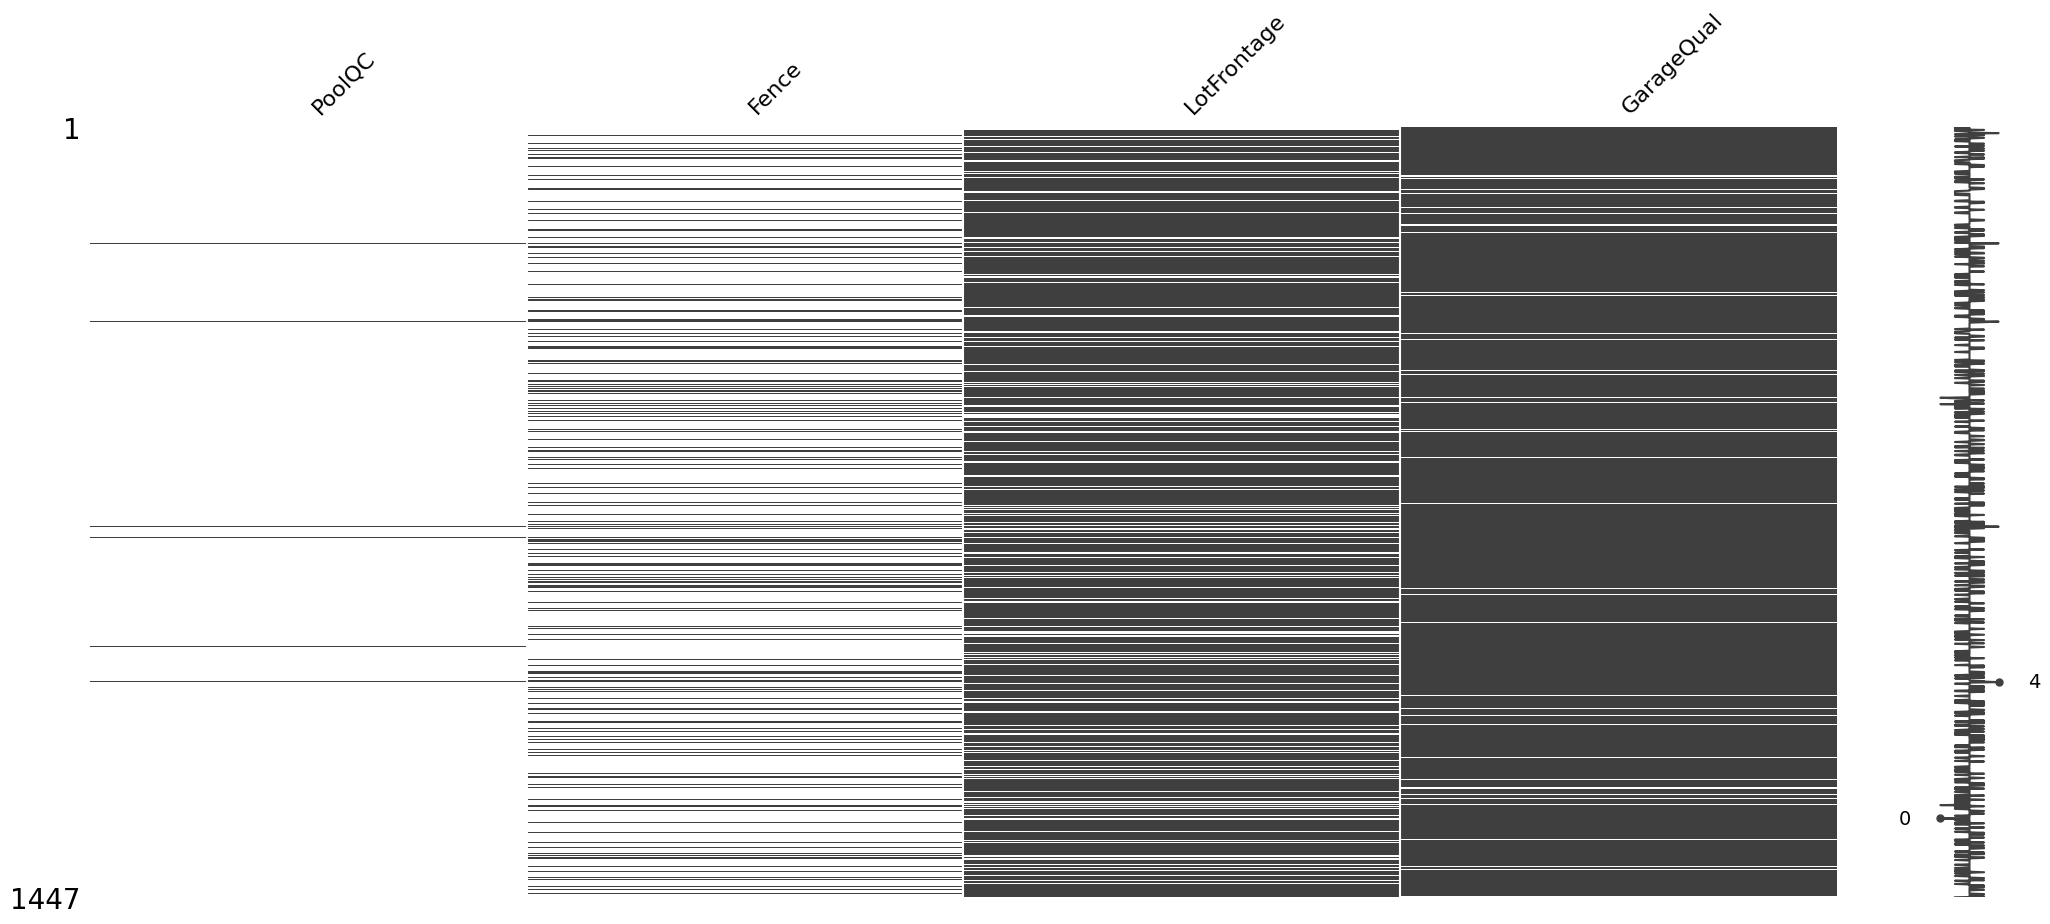


 Heatmap de correlacion de nulidad


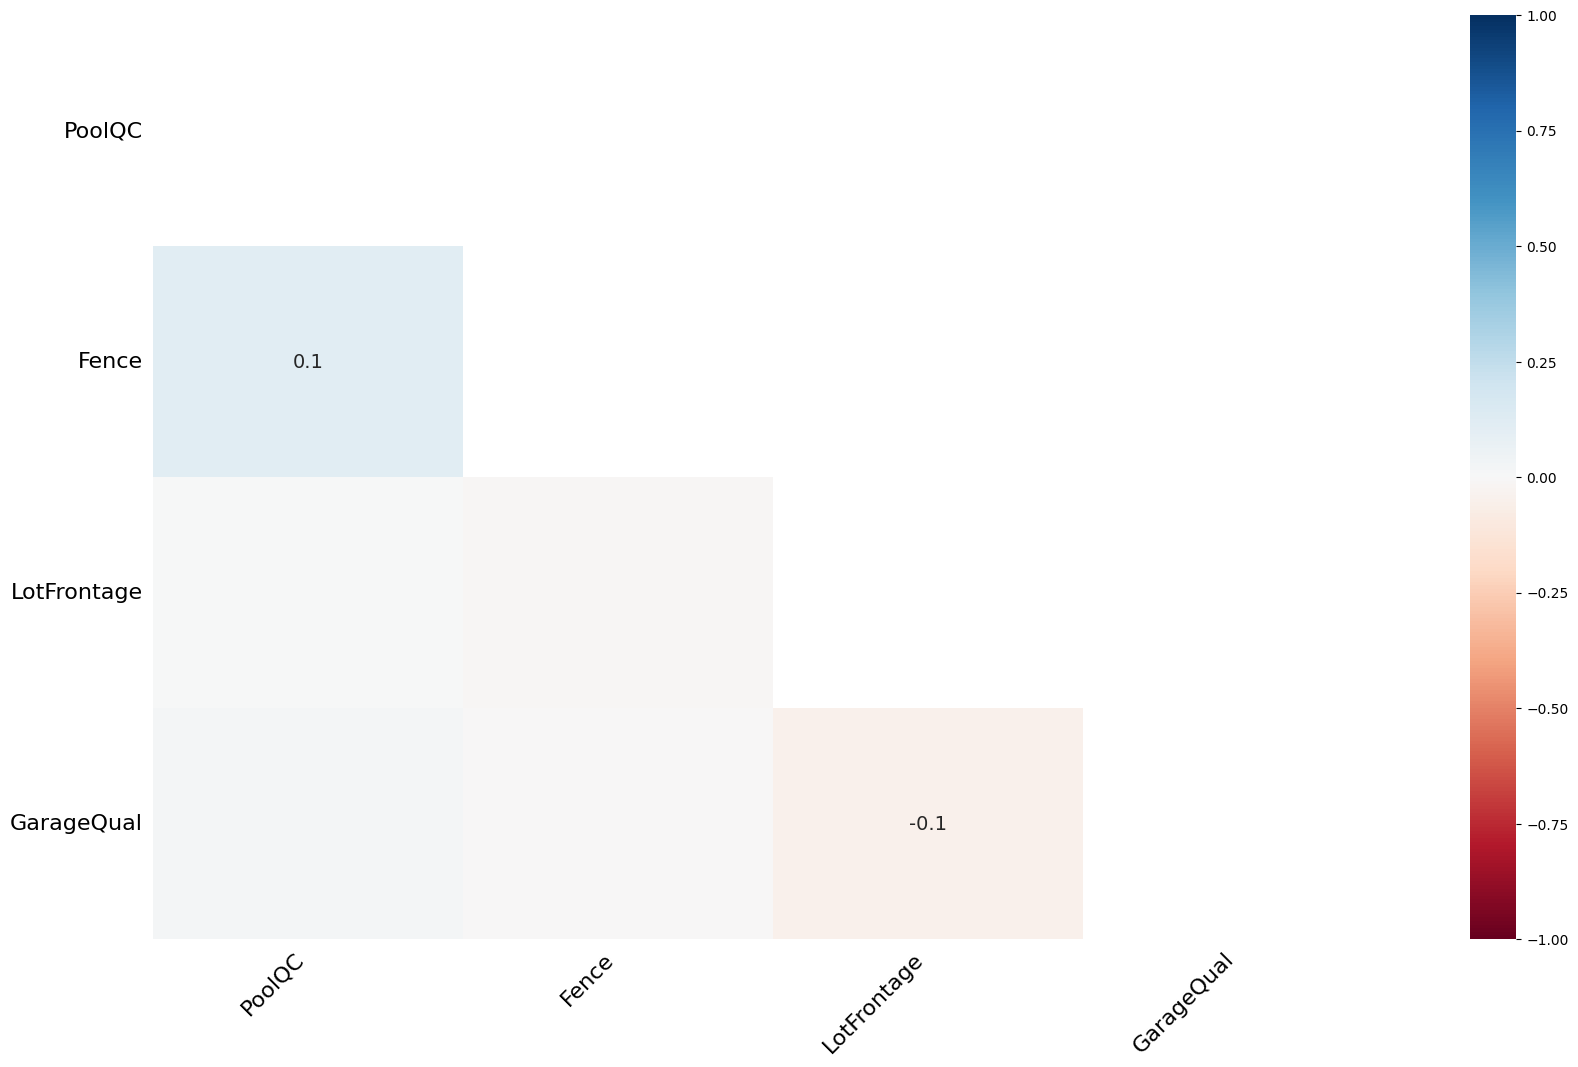

In [21]:
import missingno as msno
import matplotlib.pyplot as plt

#Usamos solo las columnas con nulos
columnas_a_graficar=columnas_con_nulos.index

print("Matriz de nulidad")
msno.matrix(df[columnas_a_graficar])
plt.show()

print("\n Heatmap de correlacion de nulidad")
#mide dee -1 a 1. Si dos columnas tienen 1 significa que si a una le falta un dato, a la otra tambien (patron MAR clasico)
msno.heatmap(df[columnas_a_graficar])
plt.show()


### Analisis de las graficas

### Comenzamos con la matriz de nulidad
Es literalmente un codigo de barras, si esta en gris es que el dato es valido en esa celda, si esta en blanco es que hay un nulo
- **PoolQC**: esta casi todo en blanco, apenas se ven lineas grises aisladas, esto es un caso tipico de MNAR (Missing Not At Random). El dato no se perdio , falta porque la casa no tiene piscina. La ausencia del dato esta relacionada con la variable misma, es informacion.
- **Fence**: Es mayoritariamente blanco, pero hay bloques  grises un poco densos, mismo que la variable anteriior, es un caso de MNAR. Lo que entiendo es que simplemente la mayoria de las casas en Ames no tienen cercas de madera o privacidad
- **LotFrontage**: Es enn su mayoria gris, pero tiene lineas blancas dispersas por todas partes. Segun lo que vimos antes le falta el 17-18% de los datos. A diferencia de las anteriores toda casa debe tener un frente.
    - Podria ser MCAR (Completamente al azar) si simplemente se olvidaron de medir el frente de forma aleatoria
    - o podria ser MAR (Al azar condicionado) si, por ejemplo, los nulos estan agrupados en casas de un barrio especifico donde no era obligatorio medir el frente.
- **GarageQual**: Es una columna casi toda gris, con unas pequeñas rayitas blancas que representan el 5% del dataset, esto es un poco raro... ya que la variale **GarageArea** no tiene valores nulos... puede ser que tengan como area=0 y esta variable queda en blanco por eso, pero quiero asegurarme de no tener una casa con GarageArea=300  pero con GarageQual= nulo, seria una ausencia de informacion. Debido a esto creo que es un MAR, ya que la ausencia del dato se puede explicar mirando otra variable, pero voy a comprobarlo en el siguiente bloque.

### Pasamos al heatmap de correlacion de nulidad (lo hice despues del analisis de abajo)

Claramente se puede ver que esta casi todo blanco, esto indica que la perdida de datos es totalmente independiente entre si, cada variable pierde datos por sus propios motivos, no estan conectadas. Obvio surge la duda de donde esta nuestro MAR que detectamos con GarageQual?. Esto se debe a que solo grafica datos que tienen nulos, como GarageArea no tiene nulos, no podemos utilizar para explicar los fatantes de GarageQual con este heatmap.


Comprobemos mi teoria sobre GarageQual

In [22]:
#Filtramos las casas donde no hay calificacion de garaje
casas_sin_GarageQual=df[df['GarageQual'].isnull()]
#vemos que tamaño de garage tienen esas casas
print("tamaño de garage en las casas donde no hay GaraQual:")
print(casas_sin_GarageQual['GarageArea'].value_counts())

tamaño de garage en las casas donde no hay GaraQual:
GarageArea
0    76
Name: count, dtype: int64


Bien, pudimos comprobar que teniamos razon y acertamos al decir que esta variable tiene un patron MAR (Missin at random/condicionado). Que tengamos como salida que los 76 datos nulos de GarageQual, tengan como GarageArea=0, nos confirma que la casa simplemente no tiene Garage....

# Inciso 2

## Implementacion de metodos de imputacion estadistica

media de LotFrontage: 70.34
mediana de LotFrontage: 70.00


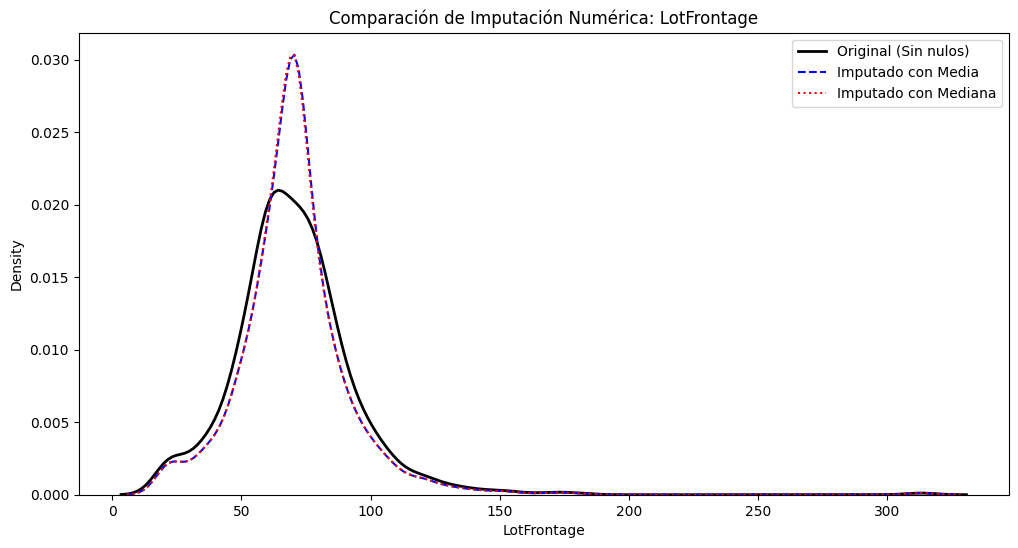

la moda de GarageQual es: TA


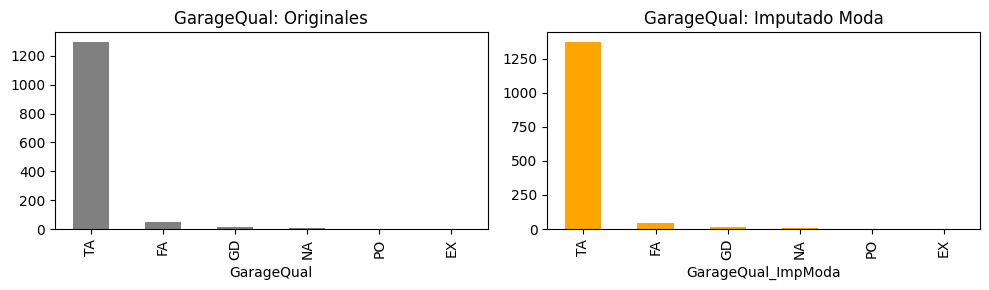



la moda de PoolQC es: GD


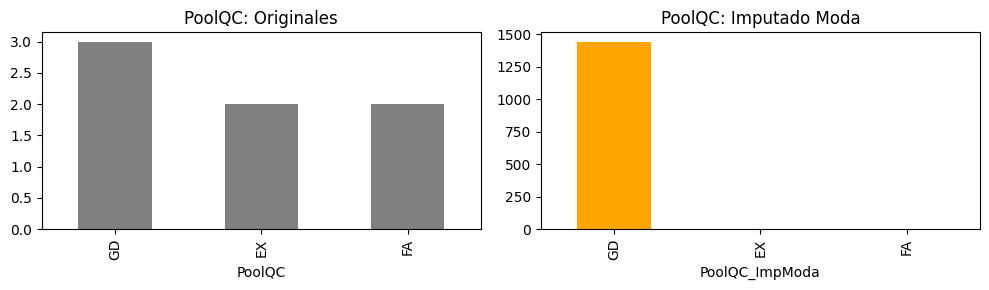



la moda de Fence es: MNPRV


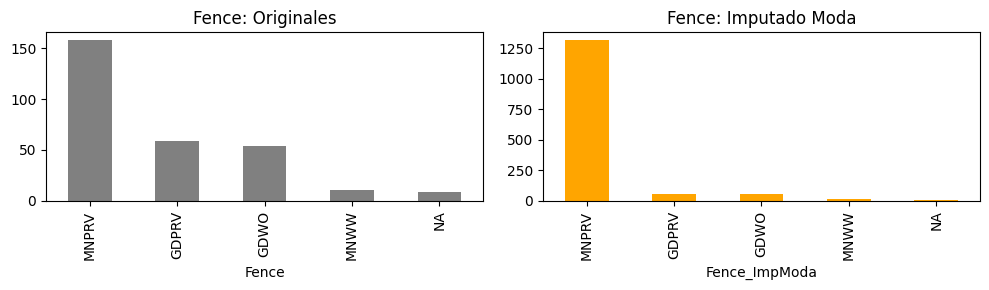

In [23]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#PARA LA VARIABLE NUMERICA (LotFrontage): media vs mediana
#extraemos los datos omitiendo temporalmente los nulos para los calculos
frontage_limpio=df['LotFrontage'].dropna()
media_frontage=np.mean(frontage_limpio)
mediana_frontage=np.median(frontage_limpio)

print(f"media de LotFrontage: {media_frontage:.2f}")
print(f"mediana de LotFrontage: {mediana_frontage:.2f}")
print("="*40)

#imputamos usando fillna y guardamos en columnas nuevas
df['LotFrontage_ImpMedia']=df['LotFrontage'].fillna(media_frontage)
df['LotFrontage_ImpMediana']=df['LotFrontage'].fillna(mediana_frontage)

#Graficamos
plt.figure(figsize=(12,6))
sns.kdeplot(frontage_limpio, label='Original (Sin nulos)', color='black', linewidth=2)
sns.kdeplot(df['LotFrontage_ImpMedia'], label='Imputado con Media', color='blue', linestyle='--')
sns.kdeplot(df['LotFrontage_ImpMediana'], label='Imputado con Mediana', color='red', linestyle=':')
plt.title('Comparación de Imputación Numérica: LotFrontage')
plt.legend()
plt.show()

#PARA LAS CATEGORICAS (GarageQual,PoolQC,Fence): Moda
columnas_categ_nulos=['GarageQual','PoolQC','Fence']
for col in columnas_categ_nulos:
    #extraemos los datos sin los nulos para calcular
    col_limpia=df[col].dropna()
    
    #calculamos la moda usando PANDAS (abajo muestro por que)
    moda_val=col_limpia.mode()[0]
    print(f"la moda de {col} es: {moda_val}")
    #imputamos y guardamos en una columna nueva
    df[f'{col}_ImpModa']=df[col].fillna(moda_val)

    #graficamos
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    df[col].value_counts().plot(kind='bar', ax=ax[0], color='gray') #grafico original
    ax[0].set_title(f'{col}: Originales')
    df[f'{col}_ImpModa'].value_counts().plot(kind='bar', ax=ax[1], color='orange') #grafico imputado
    ax[1].set_title(f'{col}: Imputado Moda')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*70 + "\n")




### Conclusion inciso 2

- **LotFrontage**: esta era la unica variable numerica con nulos, al realizar la imputacion por media y mediana, que en este caso coincidieron casi a la perfeccion, podemos notar el "pico" artificial en las curvas imputadas. Mirando la curva original se puede observar una forma de campana suave con un pequeño sesgo hacia la derecha, en las curvas imputadas, vemos claramente como se disparan hacia arriba en el valor coincidente a la media y la mediana. Esto ocurre ya que concentramos mas de 200 casas que no tenian frente en este punto y se genera este pico artificial.
        - **Media vs Mediana**: al no tener outliers extremos, la media y la mediana coincidieron casi a la perfeccion, por eso las curvas se muestran superpuestas, en este caso ninguno de los dos metodos es mejor que el otro... ambos deforman la curva de manera similar.

- **GarageQual**: ya que solo tenia el 5% de datos nulos, el metodo preservo las caracteristicas de distribucion originales.

- **PoolQC**: El grafico original muestra que solo 7 casas tienen piscinas (3 buenas, 2 excelentes, 2 regulares), mienntras que el imputado , debido a que usamos la moda, tomo a todas las casas que no tenian piscina (casi todas) y a la fuerza coloco que tienen piscinas buenas , ya que la moda era GD. Las proporciones originales desaparecieron
- **Fence**: El grafico original tenia como maximo aproximadamente 150 datos,  al imputar con la moda, el eje Y paso a tener mas de 1250 datos, esto se debe a que como la moda era MNPRV (cerca minima privacidad), se la coloco a las casi 1200 casa que no tenian cerca. Las proporciones originales desaparecieron


En resumen para las categoricas, se puede decir que el metodo de la moda NO preserva las caracteristicas distributivas originales si las variables tienen una alta tasa de ausencia. Imputar con la moda concentra artificialmente los datos en una sola categoria y queda en evidencia el cambio de las escalas de los graficos, destruyendo las frecuencias originales

### Teniamos un error usando stats.mode.... no entendia que pasaba y la IA me dijo que es por un problema de versiones, el codigo que usaba era el siguiente

In [24]:
#PARA LAS CATEGORICAS (GarageQual,PoolQC,Fence): Moda
columnas_categ_nulos=['GarageQual','PoolQC','Fence']
for col in columnas_categ_nulos:
    #extraemos los datos sin los nulos para calcular
    col_limpia=df[col].dropna()
    resultado_moda=stats.mode(col_limpia,keepdims=True)
    moda_val=resultado_moda.mode[0]
    print(f"Moda de {col}: {moda_val}")

TypeError: Argument `a` is not recognized as numeric. Support for input that cannot be coerced to a numeric array was deprecated in SciPy 1.9.0 and removed in SciPy 1.11.0. Please consider `np.unique`.

La ia dice lo siguiente:
Resulta que a partir del año 2023, los creadores de la librería scipy decidieron que su función stats.mode() ya no iba a aceptar textos ni palabras (como nuestras categorías "TA", "Gd", etc.), exigiendo que solo se use para números.

# Inciso 3

**KNN para este caso**: Si a la Casa A le falta el LotFrontage, kNN mira el resto de sus variables numéricas (tamaño del lote LotArea, año de construcción YearBuilt, precio SalePrice, etc.).
Luego, sale a buscar en todo el dataset a las 5 casas más parecidas (los 5 vecinos más cercanos matemáticamente) que SÍ tengan el dato de LotFrontage.
Toma el frente de esas 5 casas gemelas, lo promedia, y usa ese valor personalizado para rellenar el hueco de la Casa A.

- Ventaja principal: Preserva mejor la varianza y la distribución original. Al ser imputaciones "personalizadas" basadas en el contexto de cada casa, no genera un pico artificial masivo en el centro.
- Limitaciones: Es costoso computacionalmente: Para buscar vecinos, tiene que calcular la distancia matemática entre todas las filas del dataset. Sensibilidad a las escalas: Si SalePrice está en los cientos de miles y Bedroom va de 1 a 5, el precio dominará la búsqueda de similitud (deberiamos hacer un escalado previo)


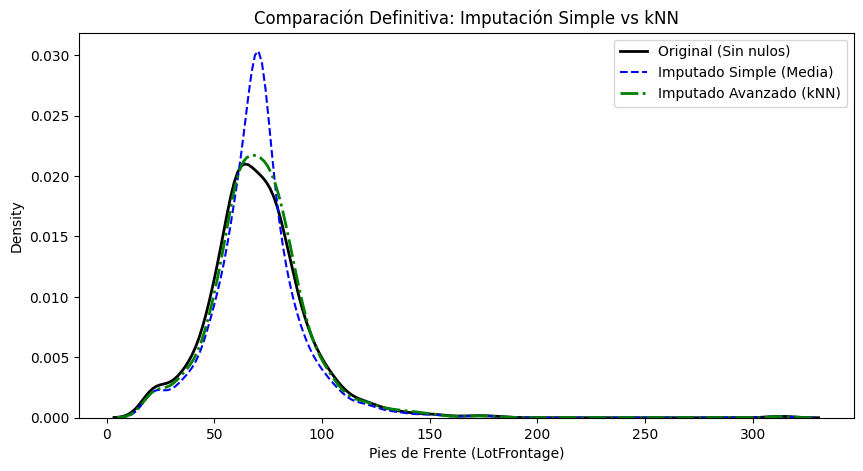

In [25]:
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

#kNN solo trabaja con numeros
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

#inicializamos el imputador, con k=5 , como esta en la teoria
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')

#Entrenamos y transformamos, esto devuelve un bloque de np asi que lo pasamos a pd
df_num_knn = pd.DataFrame(
    knn_imputer.fit_transform(df[columnas_numericas]), 
    columns=columnas_numericas, #para devolverles los nombres a las columnas
    index=df.index #para no perder el orden de nuestras filas
)
#guardamos la variable imputada en el df principal
df['LotFrontage_ImpKNN'] = df_num_knn['LotFrontage']

#comparamos
plt.figure(figsize=(10, 5))
# Curva Original (Negra)
sns.kdeplot(df['LotFrontage'].dropna(), label='Original (Sin nulos)', color='black', linewidth=2)
sns.kdeplot(df['LotFrontage_ImpMedia'], label='Imputado Simple (Media)', color='blue', linestyle='--')
# Imputacion (Verde) - kNN
sns.kdeplot(df['LotFrontage_ImpKNN'], label='Imputado Avanzado (kNN)', color='green', linestyle='-.', linewidth=2)
plt.title('Comparación Definitiva: Imputación Simple vs kNN')
plt.xlabel('Pies de Frente (LotFrontage)')
plt.legend()
plt.show()

Podemos ver claramente que la imputacion por KNN tiene casi la misma distribucion que la original, esto se debe a que repartio los datos faltantes a lo largo de toda la curva de forma inteligente y basada en el contexto de las casas (gracias a las otras variables numericas). Logro rellenar mas de 250 huecos sin crear un pico en el centro.


# EJERCICIO 3: Detección y Tratamiento de Valores Atípicos

# Inciso 1 

## Detección mediante métodos estadísticos univariados:

Sobre el z-score:
-  El Z-Score tradicional (stats.zscore) calcula a cuántas "desviaciones estándar" del promedio está un dato. El problema es que los propios outliers arruinan el promedio y la desviación estándar. La teoria propone usar la mediana como centro y el MAD (mediana de desviaciones absolutas, como medida de dispersion).
    - Si la fórmula da mayor a 3.5, es outlier. Es un método mucho más estricto y conservador que el IQR.

sobre Percentiles Extremos:
- No hace calculos complejos, basicamente dice: "Todo lo que esté por debajo del 1% más bajo (Percentil 0.01) o por encima del 1% más alto (Percentil 0.99) es un outlier".
    - Limitacion : si el dataset es perfecto y no tiene outliers, el metodo igual va a eliminar el 2% de los datos.



In [26]:
todas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
#sacamos las que agregamos en la imputacion
columnas_numericas = [col for col in todas_numericas if '_Imp' not in col]

#diccionario para guardar el conteo y armar una tabla al final
resultados_outliers = {}
for col in columnas_numericas:
    #limpiamos los nulos
    data = df[col].dropna()
    if len(data) == 0: #saltamos si la columna quedo vacia
        continue 

    #METODO IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR_val = Q3 - Q1
    limite_inf_iqr = Q1 - 1.5 * IQR_val
    limite_sup_iqr = Q3 + 1.5 * IQR_val
    #filtramos tal cual lo hace en la teoria, con el simbolo rancio "|"" (en mi PC es con altgr+1)
    #es el "O logico" de pandas, no se puede usar la palabra or
    outliers_iqr = data[(data < limite_inf_iqr) | (data > limite_sup_iqr)]

    #METODO Z-SCORE CON MEDIANA Y MAD
    median = data.median()
    #calculamos el MAD como indica la teoria
    mad = np.median(np.abs(data - median))
    #evitamos dividir por cero si el MAD es 0
    if mad == 0:
        outliers_zmod_count = 0
    else:
        constante_mad = 0.6745
        modified_z_scores = constante_mad * (data - median) / mad
        outliers_zmod = data[np.abs(modified_z_scores) > 3.5]
        outliers_zmod_count = len(outliers_zmod)

    #METODO PERCENTILES EXTREMOS (1% Y 99%)
    #la teoria usa .quantile , asi que lo uso. En la consigna decia np.percentile pero probe y es lo mismo
    p1 = data.quantile(0.01)
    p99 = data.quantile(0.99)
    outliers_percentil = data[(data < p1) | (data > p99)]

    #guardamos los resultados
    resultados_outliers[col] = {
        'Total_Datos': len(data),
        'Atípicos_IQR': len(outliers_iqr),
        'Atípicos_ZModificado': outliers_zmod_count,
        'Atípicos_Percentiles': len(outliers_percentil)
    }

#convertimos a df
df_comparacion = pd.DataFrame(resultados_outliers).T
display(df_comparacion)

,Total_Datos,Atípicos_IQR,Atípicos_ZModificado,Atípicos_Percentiles
SalePrice,1447,60,50,30
LotFrontage,1193,86,28,12
LotArea,1447,78,57,22
OverallCond,1447,124,0,6
YearBuilt,1447,7,0,16
FullBath,1447,0,0,9
BedroomAbvGr,1447,35,0,14
GarageArea,1447,20,7,15
PoolArea,1447,7,0,7


### Analisis de la tabla

- **METODO IQR**: Es claramente el mas agresivo de todos, fue el metodo que mas outliers detecto en cada variable. En 'OverallCond' detecto 124 outliers (y son valores tipo puntaje del 1 al 10 en esta variable pq explican la condicion de la casa), esto es casi el 10% del dataset. Esto pasa pq el 50% probablemente tenga de condicion 5,6 o 7, entonces el rango es pequeño y cualquier casa en condicion de 2 o 9 es maracada como "anormal". La conclusion de este metodo es que es excelente para variables continuas como 'SalePrice' o 'LotArea' pero fracasa generando falsos positivas en variables discretas (escalas de puntuacion o cantidad de habitaciones)
- **METODO Z-Score modificado**: En variables como'OverallCond','YearBuilt',FullBath' y 'BedroomAbvGr' no detecto outliers, este metodo al estar condicionado con la mediana y el MAD, entiende que tener 4 habitaciones o 3 baños no es algo anormal, es simplemente un extremo normal de un dato en particular. Solo salta que hay outliers cuando algo es exagerado en relacion a la dispersion, como por ejemplo en 'SalePrice' donde detecto 50 outliers. En mi opinion es el metodo mas confiable, no se deja engañar por saltos particulares.
- **METODO Percentiles Extremos**: Este metodo medio que forzo la aparicion de outliers en todas las varaibles, digo forzo pq por ejemplo en 'FullBath' , ninguno de los metodos anteriores habia detectado outliers y este loco dijo que hay 9. Esto ocurre basciamente pq le dijimos que corte el 1% mas alto y el 1% mas bajo de todo el dataset, no le importa si los datos son normales o no. Es un metodo de fuerza bruta que siempre quita una porcion de los datos aunque no existan anomalias verdaderas.

**Conclusion, el mejor es el Z-Score modificado**

# Inciso 2

## Deteccion multivariada basada en densidad (LOF)

Iba a escribir un resumen de lo que decia la teoria pero me dio paja. Esta muy bien explicada y se entendio clarito.

Para este dataset podemos dar un ejemplo de una casa que vale $100k, hasta ahi todo bien. Si despues tenemos una casa de 5k km^2 pq solo miramos el terreno, sigue estando todo bien pq hay muchas casas grandes. Pero que pasa si cruzamos los datos y vemos que una casa de 5000 km^2 vale $100k, seria un dato super raro.
Los metodos univariados jamas detectan esto pq miran las columnas por separado justamente.

Esto soluciona LOF,toma dos o mas variables y analiza la **densidad local** al dibujarlas en un grafico imaginario.
- Si un punto (una casa) está en el medio de una nube densa de otros puntos (casas de tamaño y precio similar), LOF dice: "sos normal" (y te pone un 1).
- Si un punto está solo, lejos de las nubes de puntos densas, LOF se da cuenta que algo raro pasa con esa combinacion de variables y dice: "sos un outlier en ese lugar" (y te pone un -1 por bobaso)


El algoritmo LOF detectó 119 outliers contextuales al cruzar LotArea y SalePrice.



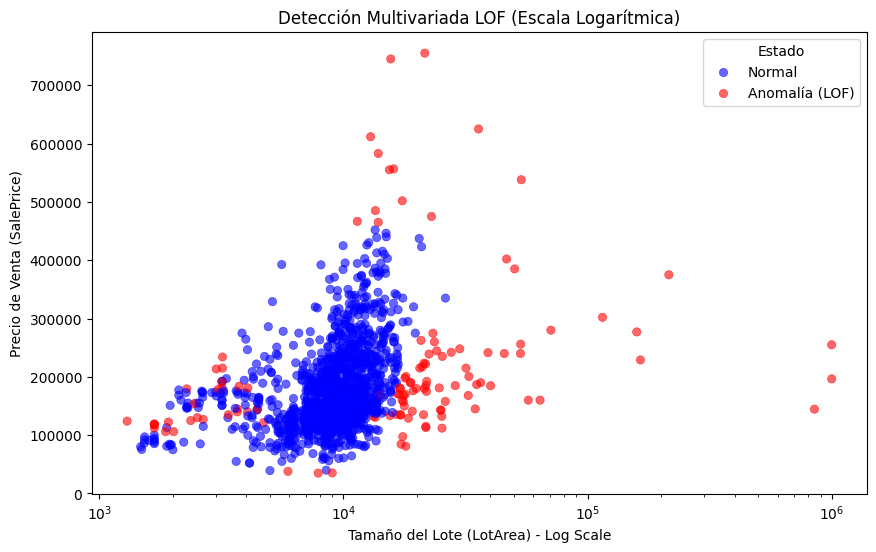

In [27]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import seaborn as sns

#elegimos dos variables numericas para cruzar (y quitamos posibles nulos por seguridad)
#uso tamaño del lote vs precio, para seguir el ejemplo
variables_lof = ['LotArea', 'SalePrice']
df_lof = df[variables_lof].dropna().copy()

#nos guiamos de la teoria para inicializar todo
# contamination='auto': Deja que el modelo decida la cantidad de outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')

#ENTRENAMOS Y PREDECIMOS
#devuelve 1  o -1 
pred_lof = lof.fit_predict(df_lof)

#creamos la mascara, tal cual la teoria
df_lof['outlier_lof'] = (pred_lof == -1)

# Contamos
total_anomalias = df_lof['outlier_lof'].sum()
print(f"El algoritmo LOF detectó {total_anomalias} outliers contextuales al cruzar {variables_lof[0]} y {variables_lof[1]}.\n")



#grafikeishon , tuve que poner una escala log al eje X pq quedaba horrible, se lo pedi a la IA dsp
# pa que lo arregle pq quedaba fiero fiero, pero bueno tmp voy a ponerme a graficar.
df_lof['Estado'] = df_lof['outlier_lof'].map({False: 'Normal', True: 'Anomalía (LOF)'})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_lof, 
    x='LotArea', 
    y='SalePrice', 
    hue='Estado', 
    palette={'Normal': 'blue', 'Anomalía (LOF)': 'red'}, 
    alpha=0.6,
    edgecolor=None
)

#ARREGLO DE ESCALA: Pasamos el eje X a escala Logarítmica para que no me quede una nube aplastada a la izquierda
plt.xscale('log')

plt.title('Detección Multivariada LOF (Escala Logarítmica)')
plt.xlabel('Tamaño del Lote (LotArea) - Log Scale')
plt.ylabel('Precio de Venta (SalePrice)')
plt.show()




A diferencia de los metodos univariados que evaluan cada variable por separado, el LOF detecta anomalias dado un contexto, evaluando la densidad del mismo. En el grafico de 'SalePrice vs LotArea' podemos ver puntos clasificados como outliers que caen dentro de rangos de precio normales, los metodos anteriores jamas hubiesen detectado estas casas como atipicas. En estos casos LOF detecto que su terreno es demasiado grande o pequeñ en relacion  a sus vecinos para tener ese precio.

### Y si lo hago con todas las numericas? No se si tiene sentido pero pruebo, cualqueir cosa lo borramos

In [28]:
# Seleccionamos TODAS las variables numericas
todas_numericas = df.select_dtypes(include=['float64', 'int64']).dropna().copy()

#quitamos las imputadas
columnas_originales = [col for col in todas_numericas if '_Imp' not in col]
df_lof_total = df[columnas_originales].dropna().copy()

columnas_usadas = df_lof_total.columns.tolist()
print(f"LOF de {len(columnas_usadas)} dimensiones.")

#inicializamos
lof_total = LocalOutlierFactor(n_neighbors=20, contamination='auto')

#predecimo
pred_lof_total = lof_total.fit_predict(df_lof_total)

#guardamos y contamos
df_lof_total['outlier_N_dimensional'] = (pred_lof_total == -1)
total_anomalias_N = df_lof_total['outlier_N_dimensional'].sum()

print(f"El algoritmo encontro {total_anomalias_N} outliers contextuales al cruzar TODAS las variables al mismo tiempo.")


LOF de 9 dimensiones.
El algoritmo encontro 90 outliers contextuales al cruzar TODAS las variables al mismo tiempo.


Bueno vemos que con 9 dimensiones el LOF detecto 90 outliers. Esta aproximacion entiendo que es la mas precisa para limpiar el datset antes de entrenar algun modelo ya que detecta interacciones anomalos entre multiples variable, por ejemplo una casa antigua , muy cara y con un terreno re chiquito y sin pileta en una zona fiera.

Al obtener menos outliers que con el LOF bidimensional (que detecto 119), podemos decir que agregar contexto resuelve falsos positivos???? fue un poco contraintuitvo esto pq pense que iba a detectar mas la verdad. Banco dejarlo y podemos charlarlo con los profes.

### HAY ALGO QUE ME HACE MUCHO RUIDO CHE, JAMAS NORMALIZAMOS NADA Y ESTAMOS COMPARANDO ENTRE VARIABLES NUMERICAS.

In [29]:
#Pruebo a ver que onda medio rapido
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

print("CON ESCALADO")
#ESCALAMOS LOS DATOS
scaler = StandardScaler()
#devuelve una matriz de numpy
datos_escalados = scaler.fit_transform(df_lof_total)

#LOF
lof_total = LocalOutlierFactor(n_neighbors=20, contamination='auto')

#Predecimos usando los datos ESCALADOS
pred_lof_total = lof_total.fit_predict(datos_escalados)

#guardamos los resultados y contamos
df_lof_total['outlier_N_dimensional_escalado'] = (pred_lof_total == -1)
total_anomalias_escalado = df_lof_total['outlier_N_dimensional_escalado'].sum()

print(f"Al escalar los datos correctamente, LOF detecto {total_anomalias_escalado} outliers contextuales.")


CON ESCALADO
Al escalar los datos correctamente, LOF detecto 159 outliers contextuales.


Bueno era medio esperable creo, era raro que den menos outliers , va no se no tengo mucha idea de si deberia dar mas o menos pero siempre pense que iba a detectar mas. Normalizando efectivamente encontro mas con 9 variables que con 2

# Inciso 3


## Estrategias de tratamiento
- **Eliminación Completa**:basicamente es: si una fila tiene un outlier, la borras por completo del dataset. Ventaja: Te deja una distribucion limpia 
Desventaja :perdemos datos. Si una casa tiene un precio normal, terreno normal, pero tiene 10 habitaciones (outlier), al borrar la fila pierdes todos sus datos buenos solo por una columna rara.
- **Winsorizacion**: no borramos a nadie, ponemos un techo y un piso a los datos (que son los percentiles 1% y 99%), los que se pasen, se adhieren a los bordes. La ventaja es que no perdemos datos la desventaja es que se crean picos en los extremos pq apilamos los outliers en los limites.
- **Truncamiento**: Es como la winsorizacion pero en lugar de percentiles, usamos los limites del IQR (Q1 y Q3). Lo malo es que reduce el efecto de los valores extremos en el modelo,pero al igual que la Winsorizacion,altera la distribucion original de los datos en los extremos. Segun la teoria su ventaja es que minimizan la influencia de los atipicos y reducen el sesgo.


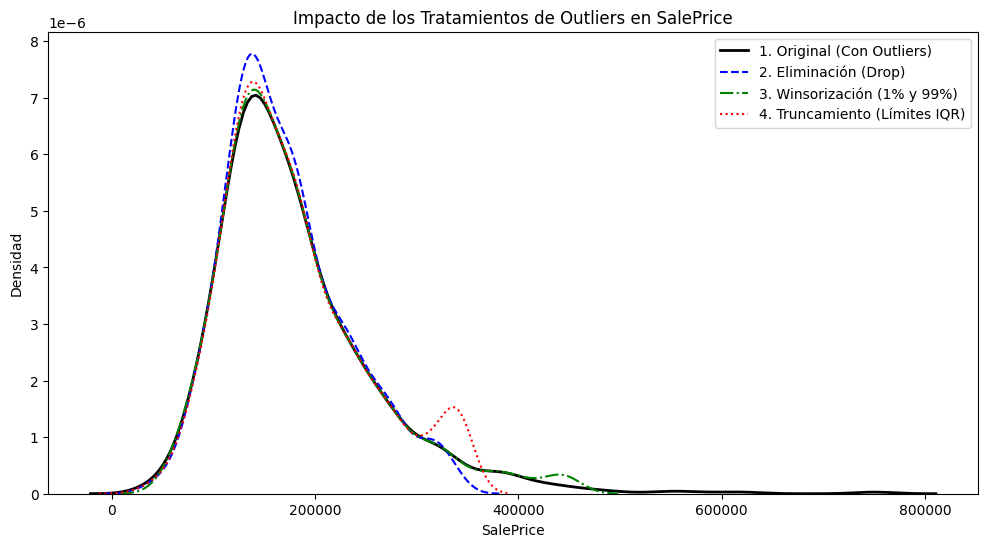

Total de datos originales: 1447
Total tras ELIMINACIÓN: 1387 (Perdimos 60 filas)
Total tras WINSORIZACIÓN: 1447 (No se pierde nada, se aplasta)
Total tras CLIPPING: 1447 (No se pierde nada, se aplasta)


In [30]:
from scipy.stats.mstats import winsorize
col = 'SalePrice'
data = df[col].dropna() #lo dejo asi aunque no tenga outliers para dsp ver las otras columnas

#Calculamos los limites IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR_val = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR_val
limite_sup = Q3 + 1.5 * IQR_val

#encontramos los outliers segun IQR para poder borrarlos luego
outliers_iqr = data[(data < limite_inf) | (data > limite_sup)]
indices_a_eliminar = outliers_iqr.index
# ESTRATEGIA 1: rliminacion completa
data_sin_outliers = data.drop(indices_a_eliminar)
# ESTRATEGIA 2: Winsorizacion
# Cortamos al 1% inferior y 1% superior 
data_winsorizada = winsorize(data, limits=[0.01, 0.01])
# ESTRATEGIA 3: Truncamiento /cClipping
# Cortamos usando los límites del IQR
data_clipped = data.clip(lower=limite_inf, upper=limite_sup)

#grafikeishon
plt.figure(figsize=(12, 6))
# Original
sns.kdeplot(data, label='1. Original (Con Outliers)', color='black', linewidth=2)
# Eliminacion
sns.kdeplot(data_sin_outliers, label='2. Eliminación (Drop)', color='blue', linestyle='--')
# Winsorizacion
sns.kdeplot(data_winsorizada, label='3. Winsorización (1% y 99%)', color='green', linestyle='-.')
# Clipping
sns.kdeplot(data_clipped, label='4. Truncamiento (Límites IQR)', color='red', linestyle=':')
plt.title('Impacto de los Tratamientos de Outliers en SalePrice')
plt.xlabel(f'{col}')
plt.ylabel('Densidad')
plt.legend()
plt.show()
# Imprimimos
print(f"Total de datos originales: {len(data)}")
print(f"Total tras ELIMINACIÓN: {len(data_sin_outliers)} (Perdimos {len(data) - len(data_sin_outliers)} filas)")
print(f"Total tras WINSORIZACIÓN: {len(data_winsorizada)} (No se pierde nada, se aplasta)")
print(f"Total tras CLIPPING: {len(data_clipped)} (No se pierde nada, se aplasta)")


### Lo hacemos para mas variables

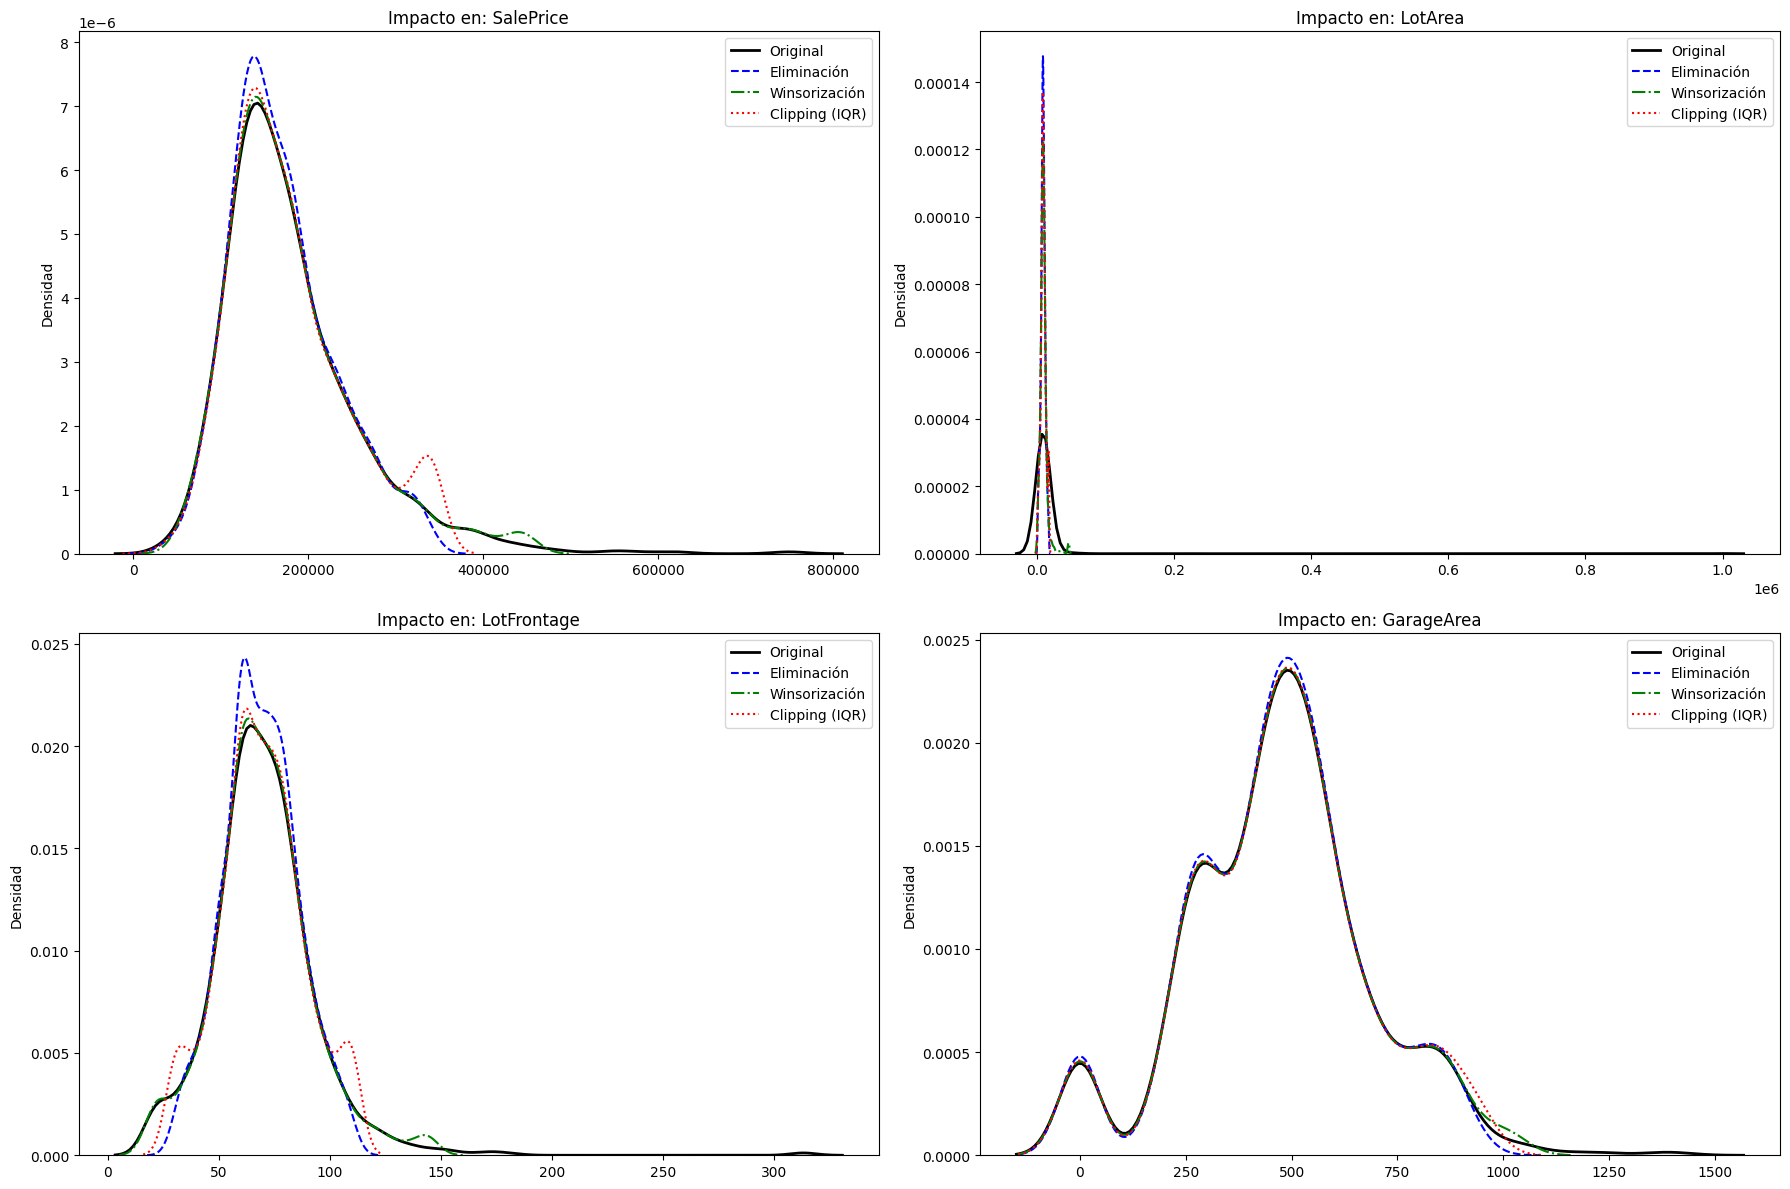

In [31]:
variables_clave = ['SalePrice', 'LotArea', 'LotFrontage', 'GarageArea']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten() #Aplanamos para iterar

for i, col in enumerate(variables_clave):
    data = df[col].dropna()
    # limites IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR_val = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR_val
    limite_sup = Q3 + 1.5 * IQR_val
    
    #tratamientos
    indices_a_eliminar = data[(data < limite_inf) | (data > limite_sup)].index
    data_sin_outliers = data.drop(indices_a_eliminar)
    data_winsorizada = winsorize(data, limits=[0.01, 0.01])
    data_clipped = data.clip(lower=limite_inf, upper=limite_sup)
    
    #grafikeishon
    sns.kdeplot(data, ax=axes[i], label='Original', color='black', linewidth=2)
    sns.kdeplot(data_sin_outliers, ax=axes[i], label='Eliminación', color='blue', linestyle='--')
    sns.kdeplot(data_winsorizada, ax=axes[i], label='Winsorización', color='green', linestyle='-.')
    sns.kdeplot(data_clipped, ax=axes[i], label='Clipping (IQR)', color='red', linestyle=':')
    
    axes[i].set_title(f'Impacto en: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

plt.tight_layout()
plt.show()


# EJERCICIO 4: CODIFICACION DE VARIABLES CATEGORICAS

# Inciso 1: Codificacion de nominales

- **Label encoding**: Ordena los barrios alfabéticamente y les asigna un número entero secuencial. (Ej: Blmngtn = 0, Blueste = 1, CollgCr = 5).
    - Sigue siendo una columna
    - Es peligroso, si luego hacemos un modelo y ve que como CollgCr es un 5 y Blueste es un 1 , creera que uno vale 5 veces mas que el otro

- **One-hot Encoding**: Como no podemos usar numeros secuenciales pq engañariamos al modelo, crea una columna de SI/NO para cada barrio.
    - No es riesgoso ya que no hay relaciones falsas, la casa tiene un 1 en su barrio y 0 en todos los demas.
    - Es medio malo en terminos de dimensionalidad, si tenemos 25 barrioos, crea 25 columnas nuevas y nos metemos en la maldicion de la dimensionalida

- **Binary Encoding**: Es un punto medio. Toma el número del Label Encoding (ej. el 5) y lo traduce a código binario informático (ej. 1 0 1). Luego crea 3 columnas para guardar esos tres dígitos.
    - No es muy interpretable para nostros aunque la maquina lo lee rapido, nosotros solo veriamos 0 y 1 sin entender mucho
    - En temas de dimensionalidad es medio problematico pero no tanto como el anterior.
    

Las unicas nominales que tenemos son '**Neighborhood**' y '**MSZoning**'

In [32]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

nominales = ['Neighborhood', 'MSZoning']
data_nominales = df[nominales].copy() 

#usamos "nunique" para contar, es basicamente number of unique y sirve para contar cuantas categorias
#distintas hay
print(f"Variables analizadas: {nominales}")
print(f"Cardinalidad Neighborhood: {data_nominales['Neighborhood'].nunique()}")
print(f"Cardinalidad MSZoning: {data_nominales['MSZoning'].nunique()}\n")

#ONE HOT ENCODING
df_onehot = pd.get_dummies(data_nominales, columns=nominales, dtype=int)
print(f"ONE-HOT ENCODING:")
print(f"Dimensionalidad: {df_onehot.shape[1]} columnas binarias.")

#LABEL ENCODING
#se aplica columna por columna
le = LabelEncoder()
df_label = data_nominales.copy()
for col in nominales:
    df_label[col] = le.fit_transform(data_nominales[col])

print(f"LABEL ENCODING:")
print(f"Dimensionalidad: {df_label.shape[1]} columnas.")

#BINARY ENCODING
be = ce.BinaryEncoder(cols=nominales)
df_binary = be.fit_transform(data_nominales)
print(f"BINARY ENCODING:")
print(f"Dimensionalidad: {df_binary.shape[1]} columnas combinadas.")

Variables analizadas: ['Neighborhood', 'MSZoning']
Cardinalidad Neighborhood: 25
Cardinalidad MSZoning: 5

ONE-HOT ENCODING:
Dimensionalidad: 30 columnas binarias.
LABEL ENCODING:
Dimensionalidad: 2 columnas.
BINARY ENCODING:
Dimensionalidad: 8 columnas combinadas.


Se puede ver que con ONE-HOT ENCODING pasamos de tener 2 columnas a 30, tal cual explicamos anteriormente. Luego con LABEL ENCODING lo que sucede es que modifica las 2 columnas originales pero borro sus valores y le coloco numeros secuenciales en su lugar.
BINARY ENCODING por su parte quedo con 8 columnas , como tenemos aprox 25 barrios, tuvo que crear 5 columnas para poder explicarlas en el sistema binario, luego como tenemos 5 zonas, tuvo que crear 3 columnas para explicarlas. Se puede ver claramente la ventaja de dimensionalidad de este metodo con respecto a ONE-HOT ENCODING

# Inciso 2: tratamiento de variables ordinales

In [33]:
#variables ordinales
ordinales = ['GarageQual', 'PoolQC', 'Fence']
data_ordinal = df[ordinales].copy()

#creamos los diccionarios, a los nulos la funcion map los ignora
dict_calidad = {'PO': 1, 'FA': 2, 'TA': 3, 'GD': 4, 'EX': 5} # Sirve para Garage y Piscina
dict_cerca = {'MNWW': 1, 'GDWO': 2, 'MNPRV': 3, 'GDPRV': 4}

df_ordinal = data_ordinal.copy()
df_ordinal['GarageQual_Num'] = data_ordinal['GarageQual'].map(dict_calidad)
df_ordinal['PoolQC_Num'] = data_ordinal['PoolQC'].map(dict_calidad)
df_ordinal['Fence_Num'] = data_ordinal['Fence'].map(dict_cerca)

print("CODIFICACION ORDINAL:")

#juntamos las columnas originales con las numericas, intercaladas para comparar facil
visualizacion = pd.concat([
    data_ordinal['GarageQual'], df_ordinal['GarageQual_Num'],
    data_ordinal['Fence'], df_ordinal['Fence_Num'],
    data_ordinal['PoolQC'], df_ordinal['PoolQC_Num']
], axis=1)

#RECORDEMOS QUE SOLO 7 CASAS TIENEN PILETA
print("LAS 7 CON PILETITA")
display(visualizacion.dropna(subset=['PoolQC']))

print("MOSTRAMOS 5 CON CERCA")
display(visualizacion.dropna(subset=['Fence']).sample(5, random_state=42))


CODIFICACION ORDINAL:
LAS 7 CON PILETITA


,GarageQual,GarageQual_Num,Fence,Fence_Num,PoolQC,PoolQC_Num
11,TA,3.0,GDPRV,4.0,GD,4.0
221,TA,3.0,GDPRV,4.0,EX,5.0
372,TA,3.0,MNPRV,3.0,EX,5.0
766,TA,3.0,GDPRV,4.0,FA,2.0
788,GD,4.0,GDPRV,4.0,GD,4.0
997,TA,3.0,NaN,NaN,GD,4.0
1067,TA,3.0,MNPRV,3.0,FA,2.0


MOSTRAMOS 5 CON CERCA


,GarageQual,GarageQual_Num,Fence,Fence_Num,PoolQC,PoolQC_Num
451,TA,3.0,GDPRV,4.0,NaN,NaN
1326,TA,3.0,GDWO,2.0,NaN,NaN
256,TA,3.0,MNPRV,3.0,NaN,NaN
891,TA,3.0,MNPRV,3.0,NaN,NaN
762,TA,3.0,GDPRV,4.0,NaN,NaN


# Inciso 3: Codificacion basada en frecuencias


**¿Que es el count/frecuency encoding?**: En lugar de inventar números arbitrarios (Label) o crear 30 columnas nuevas (One-Hot), esta técnica reemplaza el texto por la cantidad de veces que aparece en la tabla.
- **Count Encoding (Por Conteo)**: Si el barrio "CollgCr" aparece 150 veces en todo el dataset, reemplazamos la palabra "CollgCr" por el número 150.
- **Frequency Encoding (Por Frecuencia/Porcentaje)**: Es lo mismo, pero dividido por el total de casas. Si hay 1000 casas, el 150 se convierte en 0.15 (el 15% de las casas están en ese barrio).

CUANDO ES MAS APROPIADO USARLO?
- variables con alta cardinalidad: si por ejemplo en lugar de 25 barrios tenemos 5 mil, si hacemos one-hot encoding mandaria todo a mamar pq crearia 5 mil columnas. Por su parte el **Frequency encoding** mantiene una sola columna..
- Cuando la "rarez" importa, por ejemplo para detectar barrios lujosos.

LA desvemtaja es que si un barrio A y un barrio B tienen 45 casas cada uno, la maquina va a tomarlas como un mismo barrio pq solo lee "45". Pierde distincion

In [34]:
#INTENTO HACERLO A PATA CON PANDAS
#Lo hago solo con una variable, con la de 'Neighborhood' que es la que mas cardinalidad tiene
col_freq='Neighborhood'
data_freq= df[[col_freq]].copy()

#COUNT ENCODING
# map() busca el barrio de cada fila y lo reemplaza por ese conteo.
conteo_barrios = data_freq[col_freq].value_counts()
df_frecuencia = data_freq.copy()
df_frecuencia['Neighborhood_Count'] = data_freq[col_freq].map(conteo_barrios)

#FREQUENCY ENCODING
#Al poner normalize=True, en lugar de contar casas, nos da el porcentaje (0 a 1)
porcentaje_barrios = data_freq[col_freq].value_counts(normalize=True)
df_frecuencia['Neighborhood_Freq_Porcentaje'] = data_freq[col_freq].map(porcentaje_barrios)

#visualizamos
dic_freq=pd.DataFrame({
    'Cantidad de Casas (Count)': conteo_barrios, 
    'Porcentaje (Freq)': porcentaje_barrios.round(4) # Redondeamos a 4 decimales
})
display(dic_freq.head())

print("COMO QUEDO NUESTRO DATASET?")
print("="*40)
display(df_frecuencia.sample(5,random_state=42))


,Cantidad de Casas (Count),Porcentaje (Freq)
Neighborhood,,
NAMES,224,0.1548
COLLGCR,146,0.1009
OLDTOWN,113,0.0781
EDWARDS,97,0.0670
SOMERST,83,0.0574


COMO QUEDO NUESTRO DATASET?


,Neighborhood,Neighborhood_Count,Neighborhood_Freq_Porcentaje
1047,SAWYERW,59,0.040774
388,COLLGCR,146,0.100898
862,EDWARDS,97,0.067035
434,NAMES,224,0.154803
194,NAMES,224,0.154803


No tiene sentido para mi hacerlo en **GarageQual** o **Fence** por ejemplo porque son variables ordinales y podriamos destruir la jerarquia.
**MSZoning** por su parte solo tiene 5 zonas, es de baja cardinalidad y segun la teoria este metodo se utiliza para altas cardinalidades

# Ejercicio 5:


In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1447 entries, 0 to 1486
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SalePrice               1447 non-null   float64
 1   MSZoning                1447 non-null   object 
 2   Neighborhood            1447 non-null   object 
 3   LotFrontage             1193 non-null   float64
 4   LotArea                 1447 non-null   int64  
 5   OverallCond             1447 non-null   int64  
 6   YearBuilt               1447 non-null   int64  
 7   FullBath                1447 non-null   int64  
 8   BedroomAbvGr            1447 non-null   int64  
 9   GarageQual              1371 non-null   object 
 10  GarageArea              1447 non-null   int64  
 11  PoolArea                1447 non-null   int64  
 12  PoolQC                  7 non-null      object 
 13  Fence                   291 non-null    object 
 14  LotFrontage_ImpMedia    1447 non-null   float

In [36]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

todas_numericas_1= df.select_dtypes(include=['float64', 'int64']).copy()


#Ahora borramos las columnas LotFrontage_ImpMedia, LotFrontage_ImpMediana y LotFrontage
todas_numericas_1=todas_numericas_1.drop(columns=['LotFrontage_ImpMedia', 'LotFrontage_ImpMediana', 'LotFrontage'])
todas_numericas_1.info()


data_num = todas_numericas_1.copy()
minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

#aplicamos los escaladores
df_minmax = pd.DataFrame(minmax.fit_transform(data_num), columns=data_num.columns)
df_standard = pd.DataFrame(standard.fit_transform(data_num), columns=data_num.columns)
df_robust = pd.DataFrame(robust.fit_transform(data_num), columns=data_num.columns)


<class 'pandas.core.frame.DataFrame'>
Index: 1447 entries, 0 to 1486
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SalePrice           1447 non-null   float64
 1   LotArea             1447 non-null   int64  
 2   OverallCond         1447 non-null   int64  
 3   YearBuilt           1447 non-null   int64  
 4   FullBath            1447 non-null   int64  
 5   BedroomAbvGr        1447 non-null   int64  
 6   GarageArea          1447 non-null   int64  
 7   PoolArea            1447 non-null   int64  
 8   LotFrontage_ImpKNN  1447 non-null   float64
dtypes: float64(2), int64(7)
memory usage: 145.3 KB


In [37]:
resumen = pd.DataFrame({
    '1. ORIGINAL': data_num['SalePrice'].describe(),
    '2. MIN-MAX': df_minmax['SalePrice'].describe(),
    '3. STANDARD (Z-Score)': df_standard['SalePrice'].describe(),
    '4. ROBUST': df_robust['SalePrice'].describe()
})

In [38]:
display(resumen.loc[['min', 'max', 'mean', '50%']].round(3))

,1. ORIGINAL,2. MIN-MAX,3. STANDARD (Z-Score),4. ROBUST
min,34900.000,0.000,-1.840,-1.523
max,755000.000,1.000,7.202,6.973
mean,181422.076,0.203,-0.000,0.206
50%,164000.000,0.179,-0.219,0.000


In [39]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
#mantenemos la columna imputada con KNN
#Traemos todas las numericas
todas_numericas_1 = df.select_dtypes(include=['float64', 'int64']).copy()
columnas_a_borrar = ['LotFrontage', 'LotFrontage_ImpMedia', 'LotFrontage_ImpMediana', 'LotFrontage_ImpModa']

#Usamos errors='ignore' para que no crashee si alguna de estas columnas ya no existe.
todas_numericas_1 = todas_numericas_1.drop(columns=columnas_a_borrar, errors='ignore')
#Agregamos el dropna() por seguridad
data_num = todas_numericas_1.dropna().copy()


minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()
#Aplicamos los escaladores usando data_num.columns para evitar errores
df_minmax = pd.DataFrame(minmax.fit_transform(data_num), columns=data_num.columns)
df_standard = pd.DataFrame(standard.fit_transform(data_num), columns=data_num.columns)
df_robust = pd.DataFrame(robust.fit_transform(data_num), columns=data_num.columns)

#Tablas
print("="*80)
print("'SalePrice' ")
print("="*80)
resumen_precio = pd.DataFrame({
    '1. ORIGINAL': data_num['SalePrice'].describe(),
    '2. MIN-MAX': df_minmax['SalePrice'].describe(),
    '3. STANDARD (Z-Score)': df_standard['SalePrice'].describe(),
    '4. ROBUST': df_robust['SalePrice'].describe()
})
display(resumen_precio.loc[['min', 'max', 'mean', '50%']].round(3))
print("\n" + "="*80)
print("'LotArea' (Variable con OUTLIERS EXTREMOS)")
print("="*80)
resumen_area = pd.DataFrame({
    '1. ORIGINAL': data_num['LotArea'].describe(),
    '2. MIN-MAX': df_minmax['LotArea'].describe(),
    '3. STANDARD (Z-Score)': df_standard['LotArea'].describe(),
    '4. ROBUST': df_robust['LotArea'].describe()
})
display(resumen_area.loc[['min', 'max', 'mean', '50%']].round(3))

'SalePrice' 


,1. ORIGINAL,2. MIN-MAX,3. STANDARD (Z-Score),4. ROBUST
min,34900.000,0.000,-1.840,-1.523
max,755000.000,1.000,7.202,6.973
mean,181422.076,0.203,-0.000,0.206
50%,164000.000,0.179,-0.219,0.000



'LotArea' (Variable con OUTLIERS EXTREMOS)


,1. ORIGINAL,2. MIN-MAX,3. STANDARD (Z-Score),4. ROBUST
min,1300.000,0.000,-0.255,-2.059
max,1000000.000,1.000,22.441,247.991
mean,12534.597,0.011,-0.000,0.754
50%,9525.000,0.008,-0.068,0.000


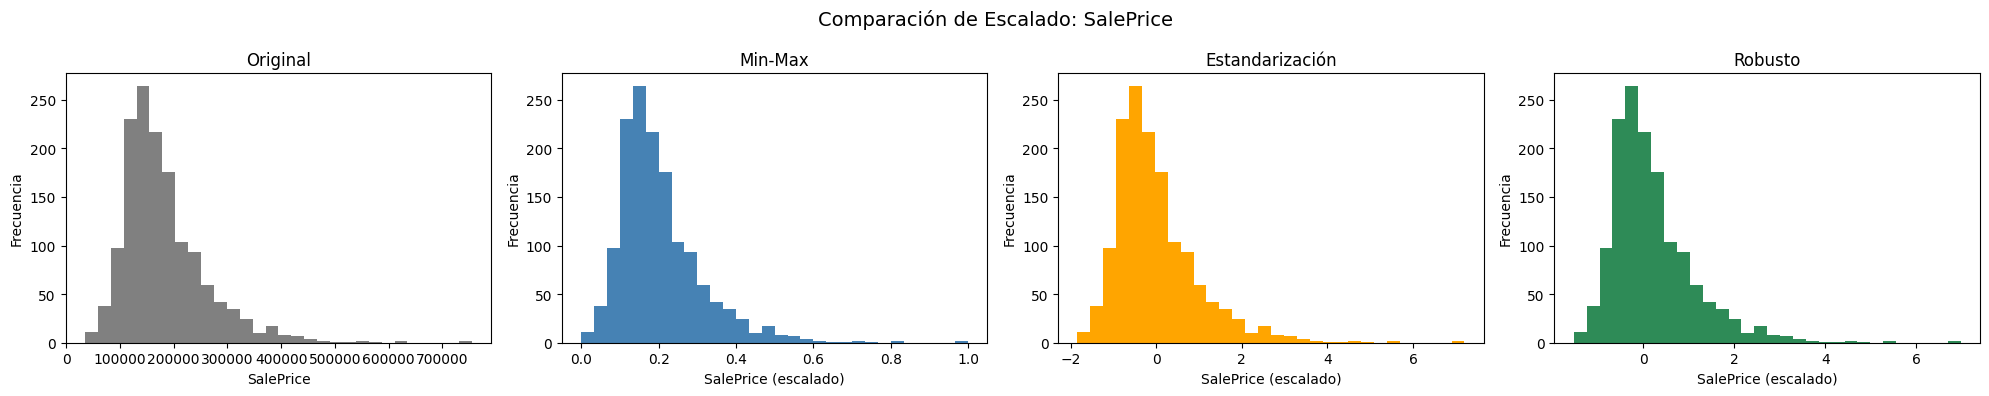

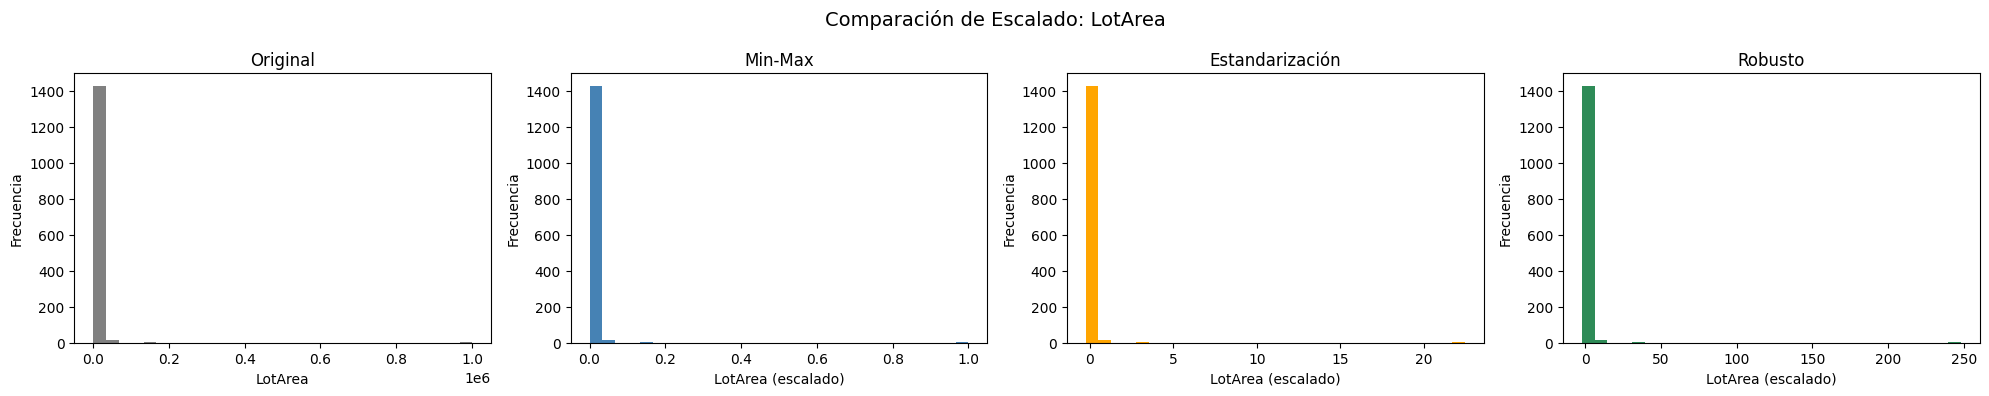

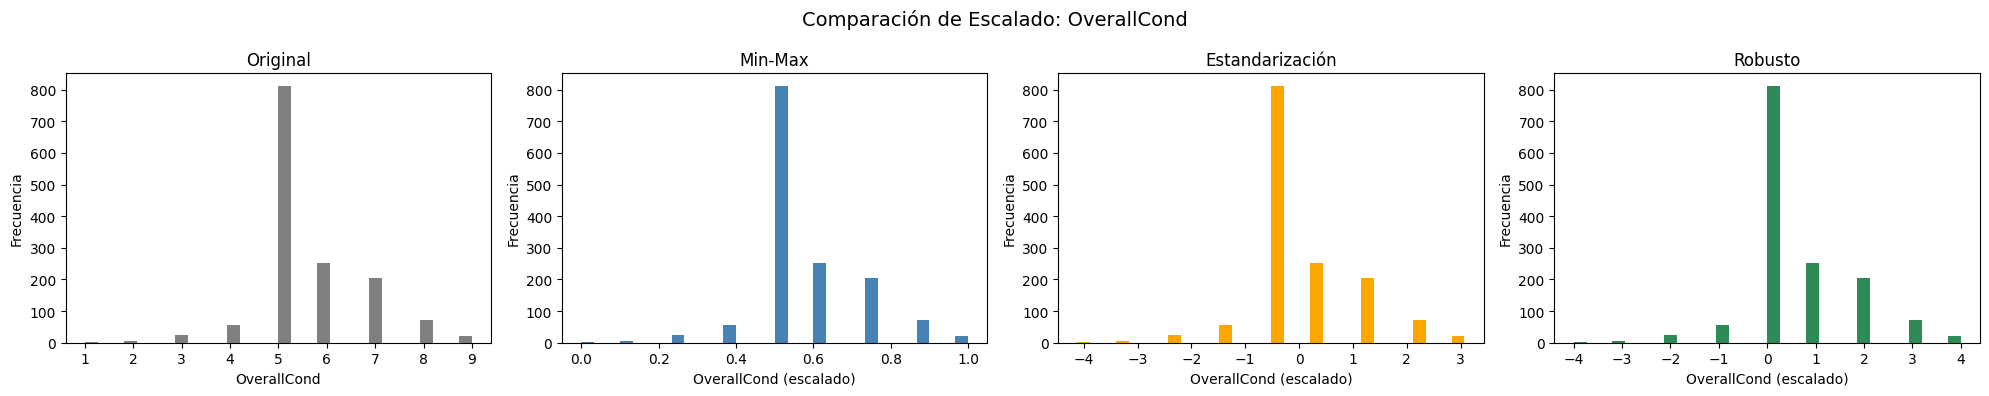

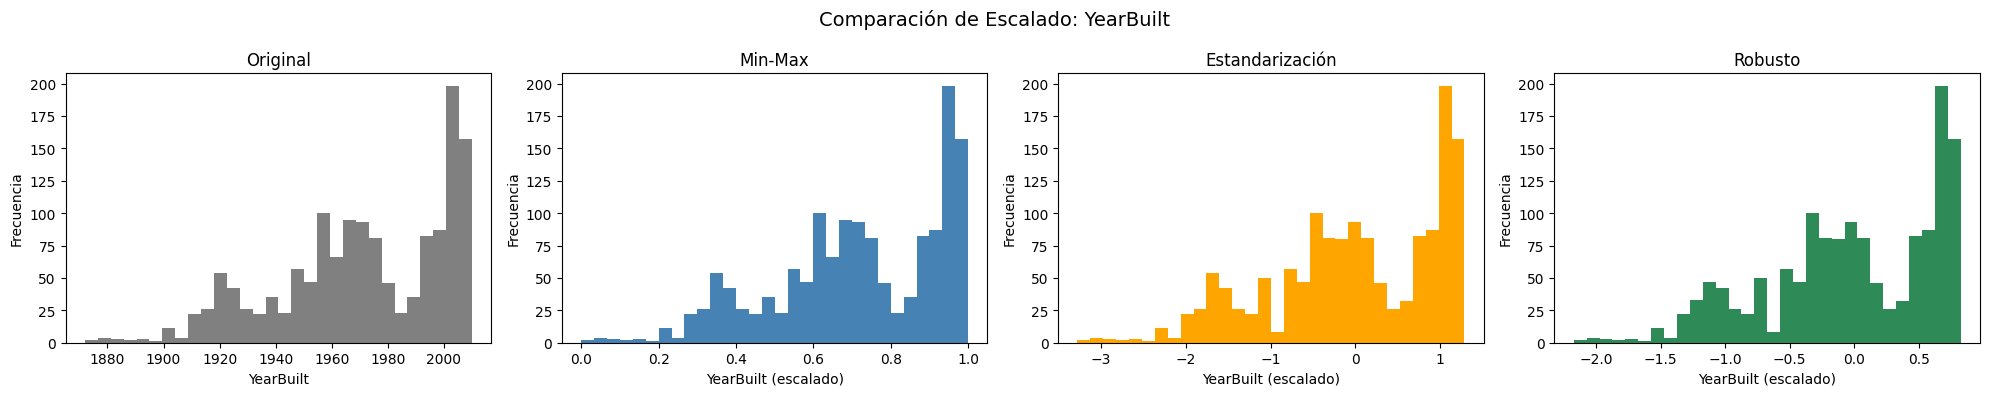

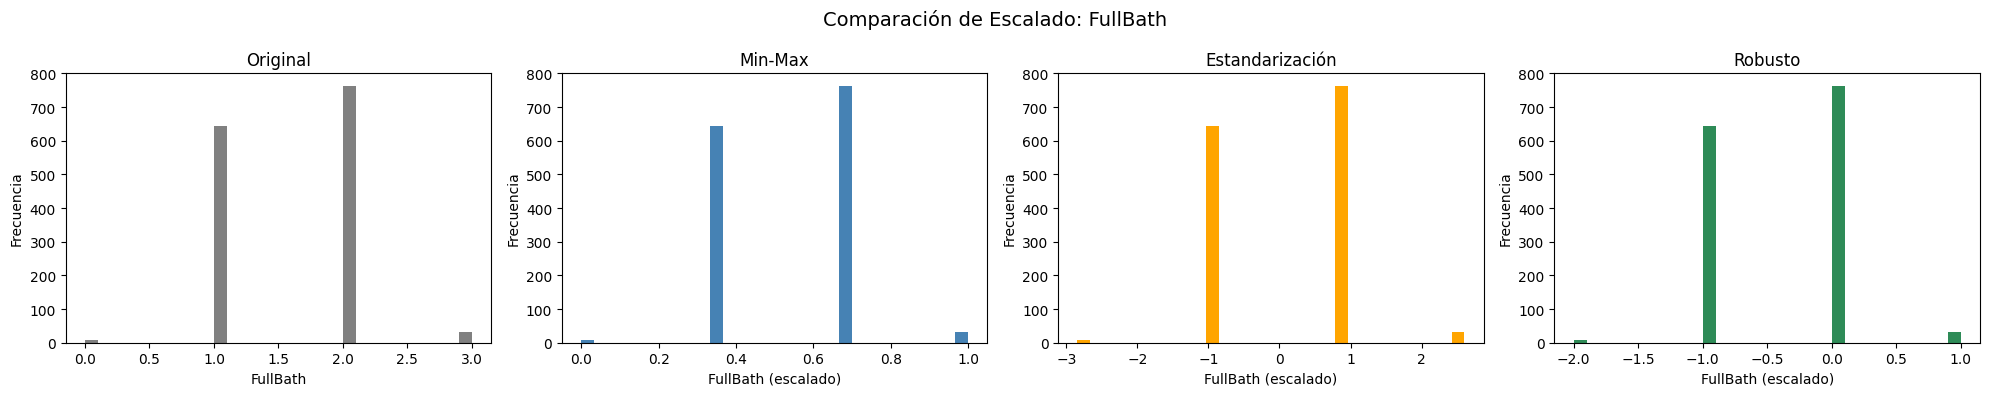

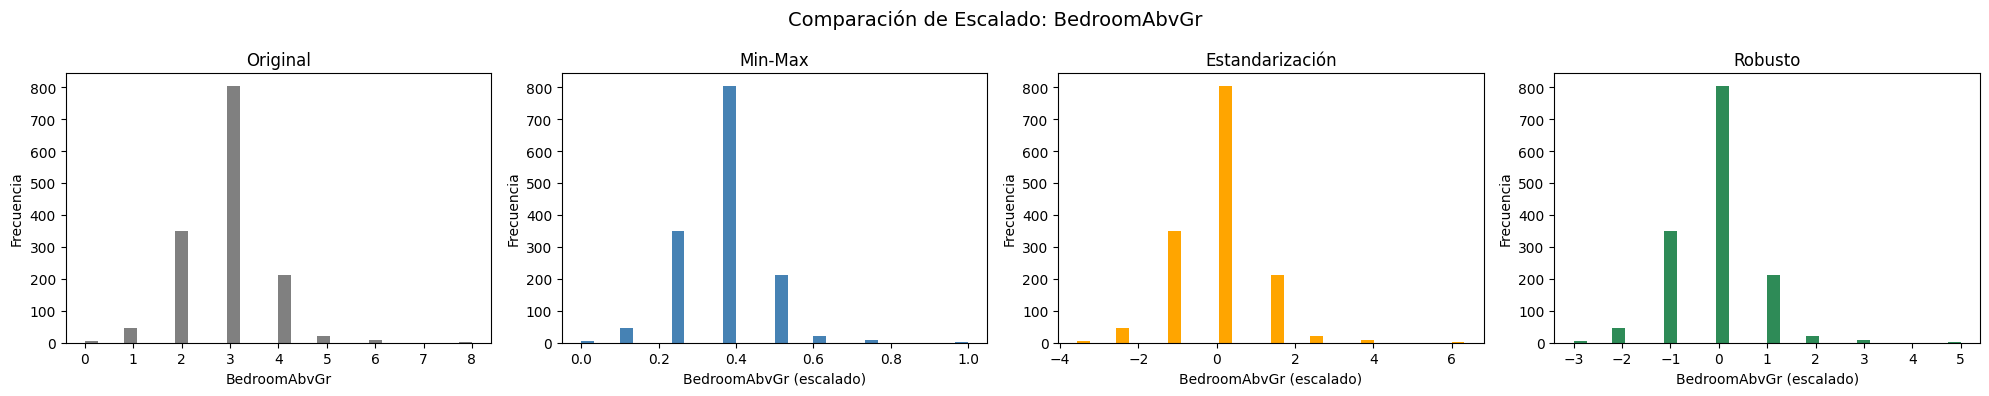

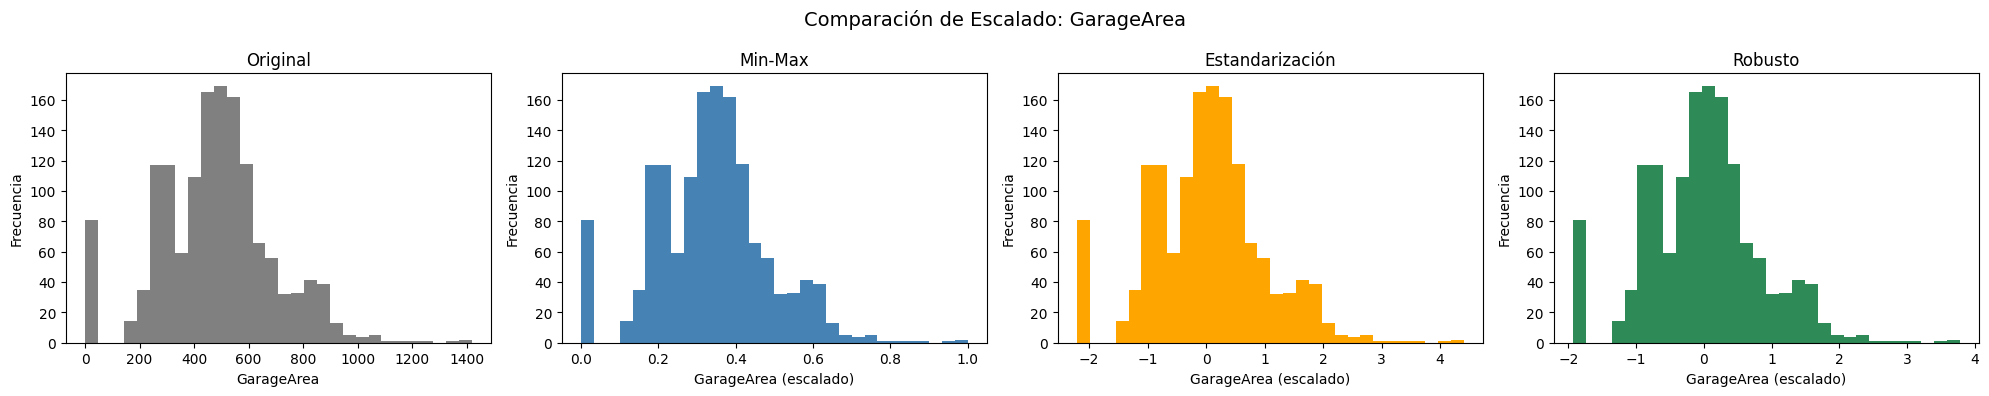

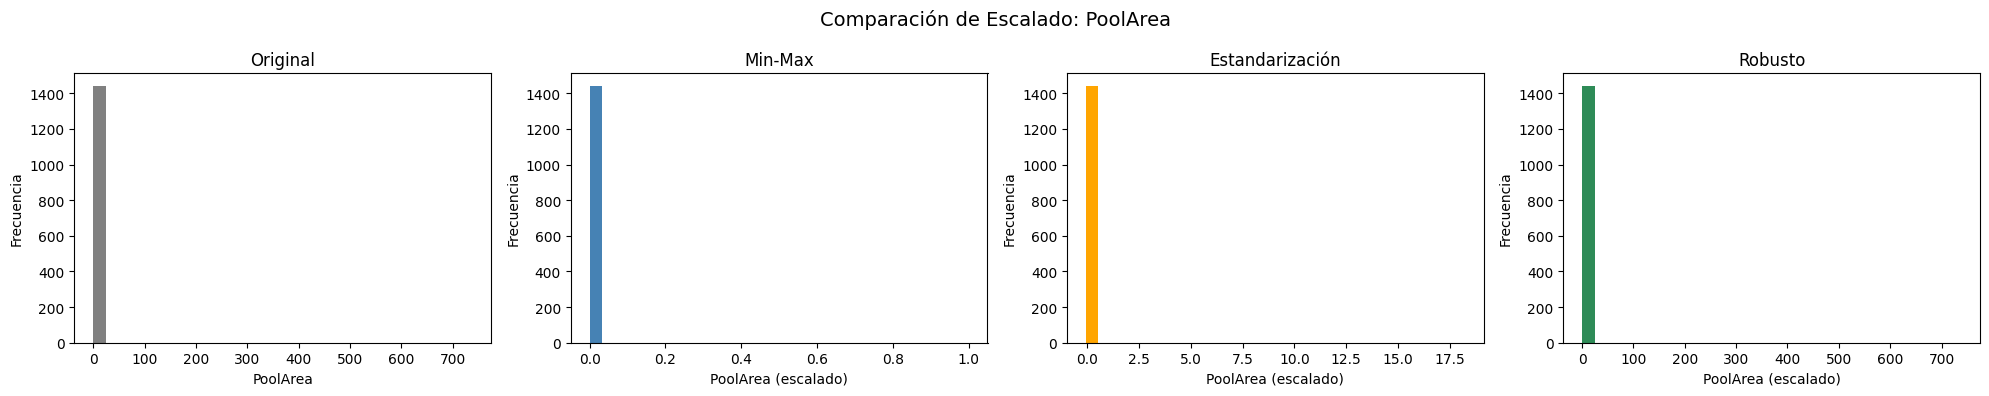

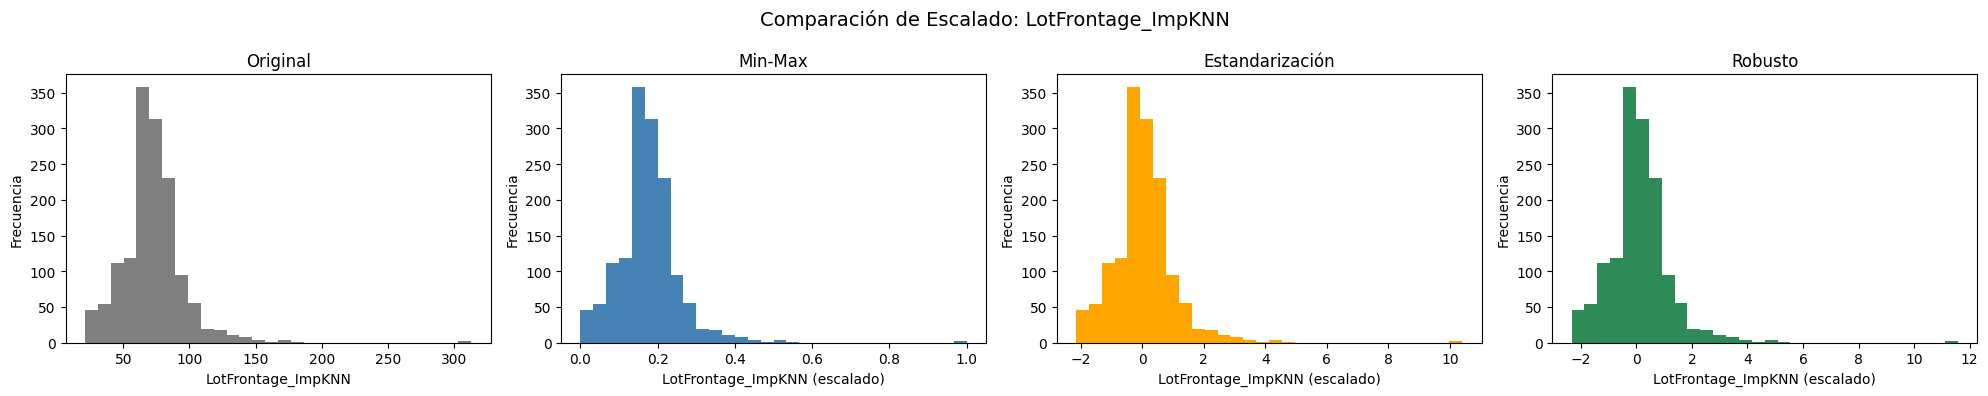

In [40]:
import matplotlib.pyplot as plt

for col in data_num.columns:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].hist(data_num[col], bins=30, color='gray')
    axes[0].set_title('Original')
    axes[0].set_xlabel(col)

    axes[1].hist(df_minmax[col], bins=30, color='steelblue')
    axes[1].set_title('Min-Max')
    axes[1].set_xlabel(f'{col} (escalado)')

    axes[2].hist(df_standard[col], bins=30, color='orange')
    axes[2].set_title('Estandarización')
    axes[2].set_xlabel(f'{col} (escalado)')

    axes[3].hist(df_robust[col], bins=30, color='seagreen')
    axes[3].set_title('Robusto')
    axes[3].set_xlabel(f'{col} (escalado)')

    for ax in axes:
        ax.set_ylabel('Frecuencia')

    fig.suptitle(f'Comparación de Escalado: {col}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Inciso 2

In [41]:
#Realizamos las transformaciones de logaritmo natural y raíz cuadrada para las variables numéricas
data_log = data_num.copy()
data_log = np.log1p(data_log)  # log(1 + x) para evitar log(0)

data_sqrt = data_num.copy()
data_sqrt = np.sqrt(data_num)  # raíz cuadrada

#realizamos la transformacion de Box-Cox, que requiere que los datos sean positivos y no nulos
data_boxcox = data_num.copy()
resultados_boxcox = {}

for col in data_num.columns:
    if (data_boxcox[col] > 0).all():  # solo si es estrictamente positiva
        transformado, lam = stats.boxcox(data_num[col])
        resultados_boxcox[col] = {
            'lambda': lam,
            'skew_original': data_num[col].skew(),
            'skew_boxcox': pd.Series(transformado).skew()
        }
    else:
        resultados_boxcox[col] = {
            'lambda': None,
            'skew_original': data_num[col].skew(),
            'skew_boxcox': None
        }


#Ahora realizamos la transformacion de Yeo-Johnson, que puede manejar ceros y negativos
data_yeojohnson = data_num.copy()
resultados_yeojohnson = {}

for col in data_num.columns:
    transformado, lam = stats.yeojohnson(data_yeojohnson[col])
    resultados_yeojohnson[col] = {
        'lambda': lam,
        'skew_original': data_num[col].skew(),
        'skew_yeojohnson': pd.Series(transformado).skew()
    }



In [42]:
display(pd.DataFrame({
    'Original': data_num.skew(),
    'Logaritmo Natural': data_log.skew(),
    'Raíz Cuadrada': data_sqrt.skew(),
    'Box-Cox': [resultados_boxcox[col]['skew_boxcox'] for col in data_num.columns if col in resultados_boxcox],
    'Yeo-Johnson': [resultados_yeojohnson[col]['skew_yeojohnson'] for col in data_num.columns if col in resultados_yeojohnson]
}).round(3))

,Original,Logaritmo Natural,Raíz Cuadrada,Box-Cox,Yeo-Johnson
SalePrice,1.869,0.109,0.930,-0.008,-0.008
LotArea,20.543,1.094,12.582,-0.185,-0.185
OverallCond,0.691,-0.255,0.185,0.074,0.032
YearBuilt,-0.606,-0.634,-0.620,-0.132,-0.132
FullBath,0.035,-0.399,-0.787,NaN,-0.050
BedroomAbvGr,0.228,-1.251,-1.271,NaN,0.128
GarageArea,0.173,-3.465,-1.596,NaN,-0.335
PoolArea,14.761,14.298,14.399,NaN,14.288
LotFrontage_ImpKNN,2.063,-0.782,0.329,0.136,0.130


# Inciso 3

In [43]:
from scipy.stats import shapiro

# Armamos los DataFrames completos de Box-Cox y Yeo-Johnson
# (antes solo tenías lambda y skew guardados, ahora necesitamos los valores transformados en sí)
df_boxcox = data_num.copy()
df_yeojohnson = data_num.copy()

for col in data_num.columns:
    # Box-Cox solo se puede aplicar si la columna es estrictamente positiva
    if resultados_boxcox[col]['lambda'] is not None:
        transformado, _ = stats.boxcox(data_num[col])
        df_boxcox[col] = transformado
    else:
        df_boxcox[col] = np.nan  # no aplica, la dejamos vacía para no graficarla ni testearla

    # Yeo-Johnson siempre se puede aplicar (soporta ceros y negativos)
    transformado, _ = stats.yeojohnson(data_num[col])
    df_yeojohnson[col] = transformado

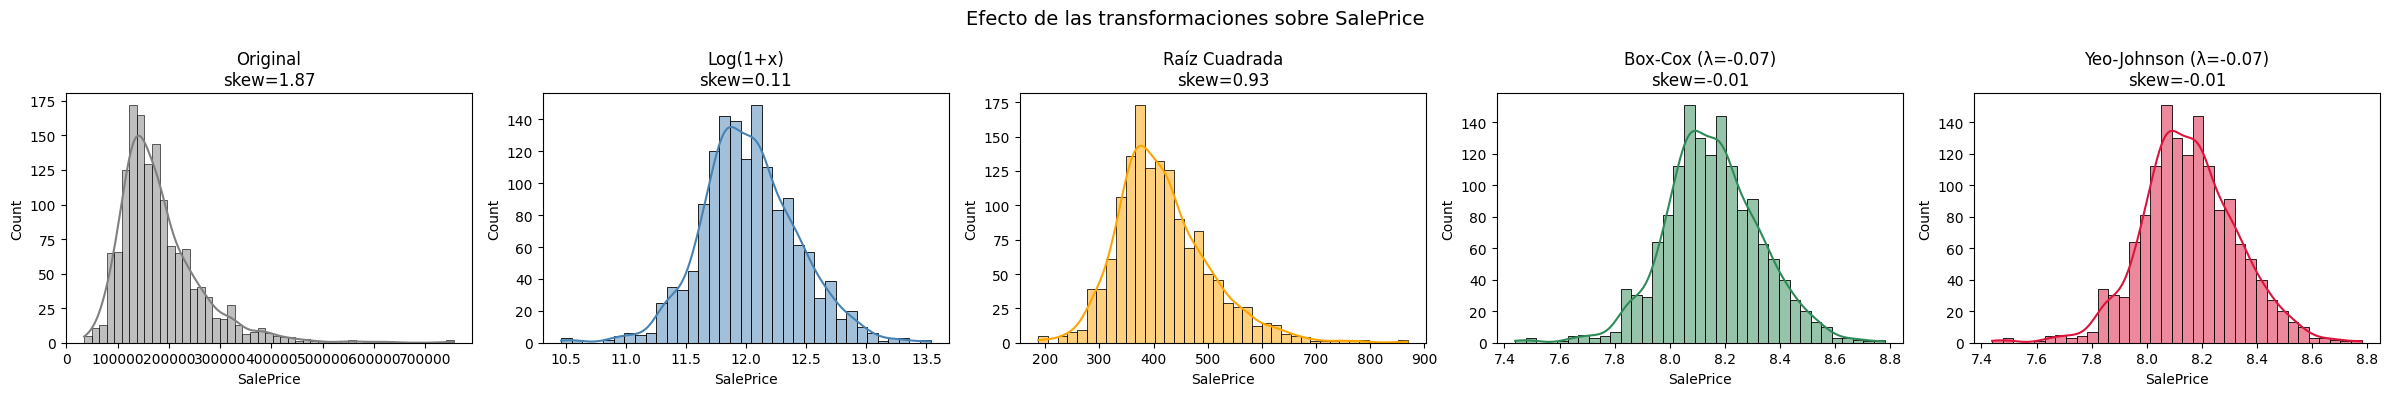

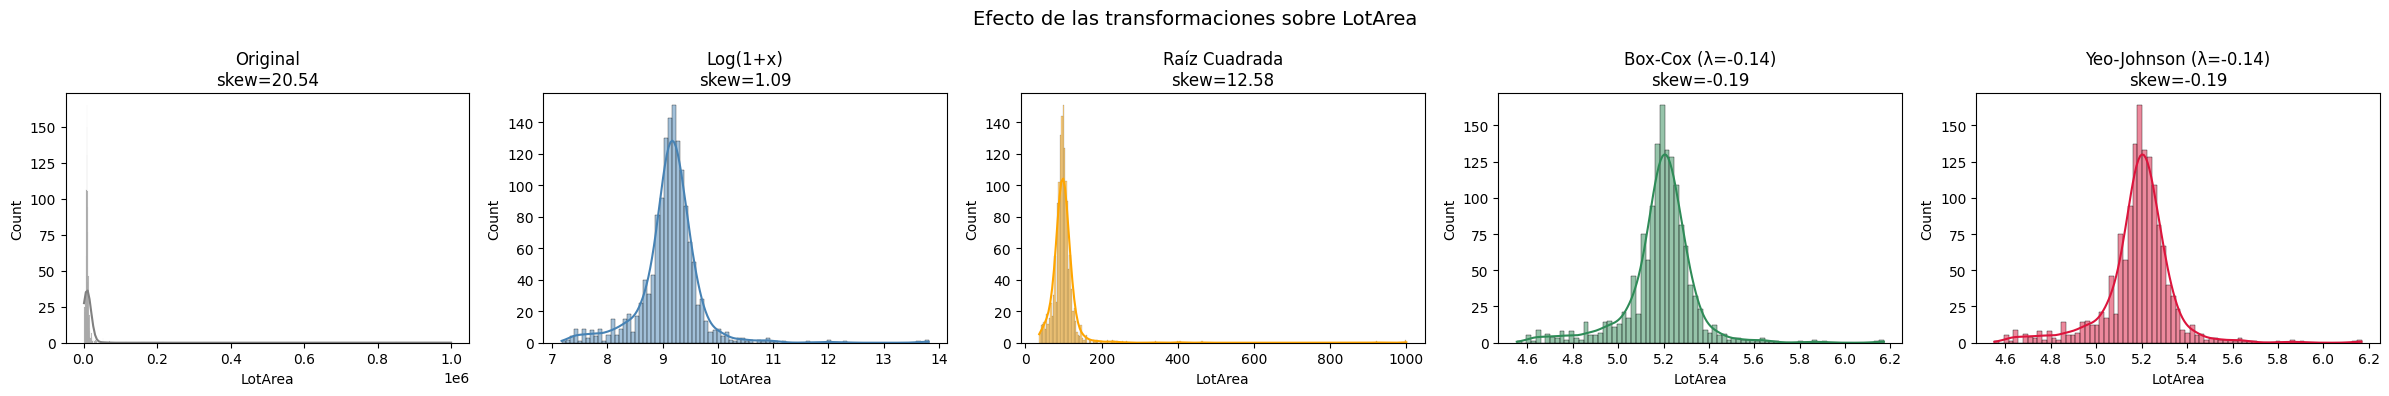

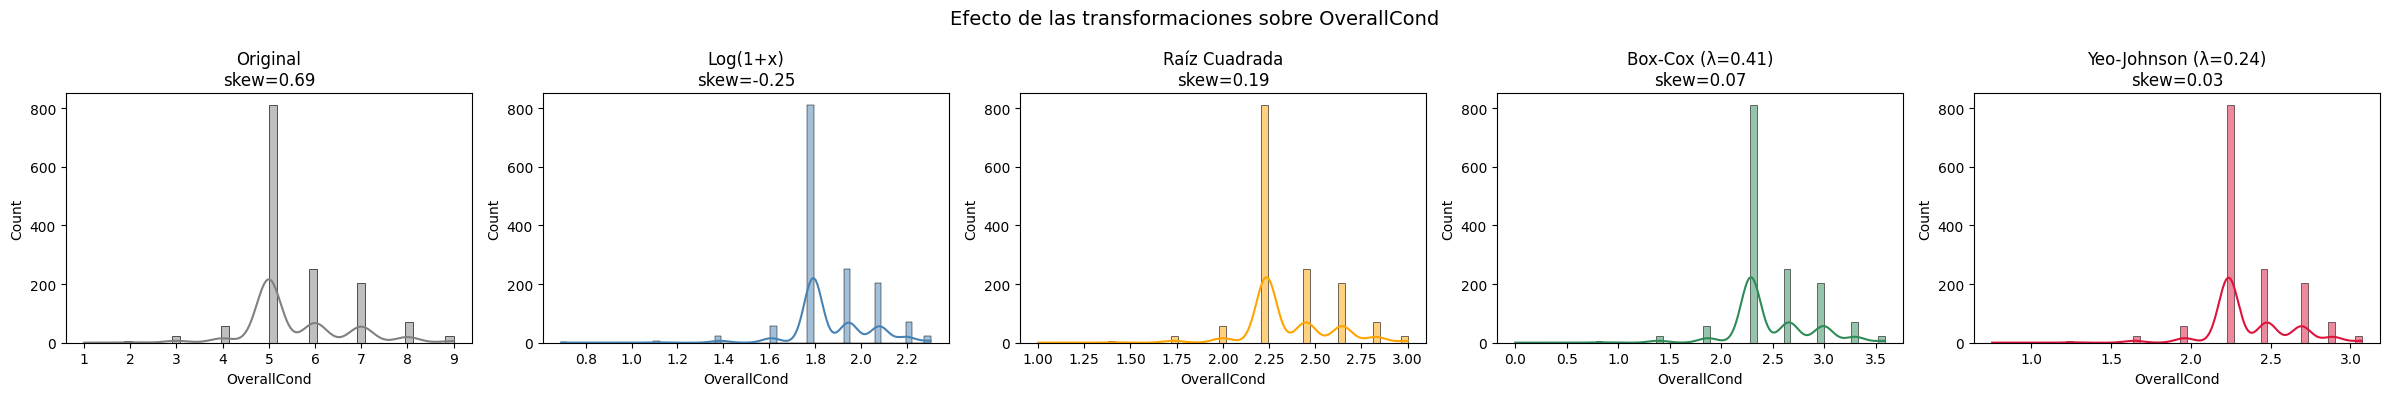

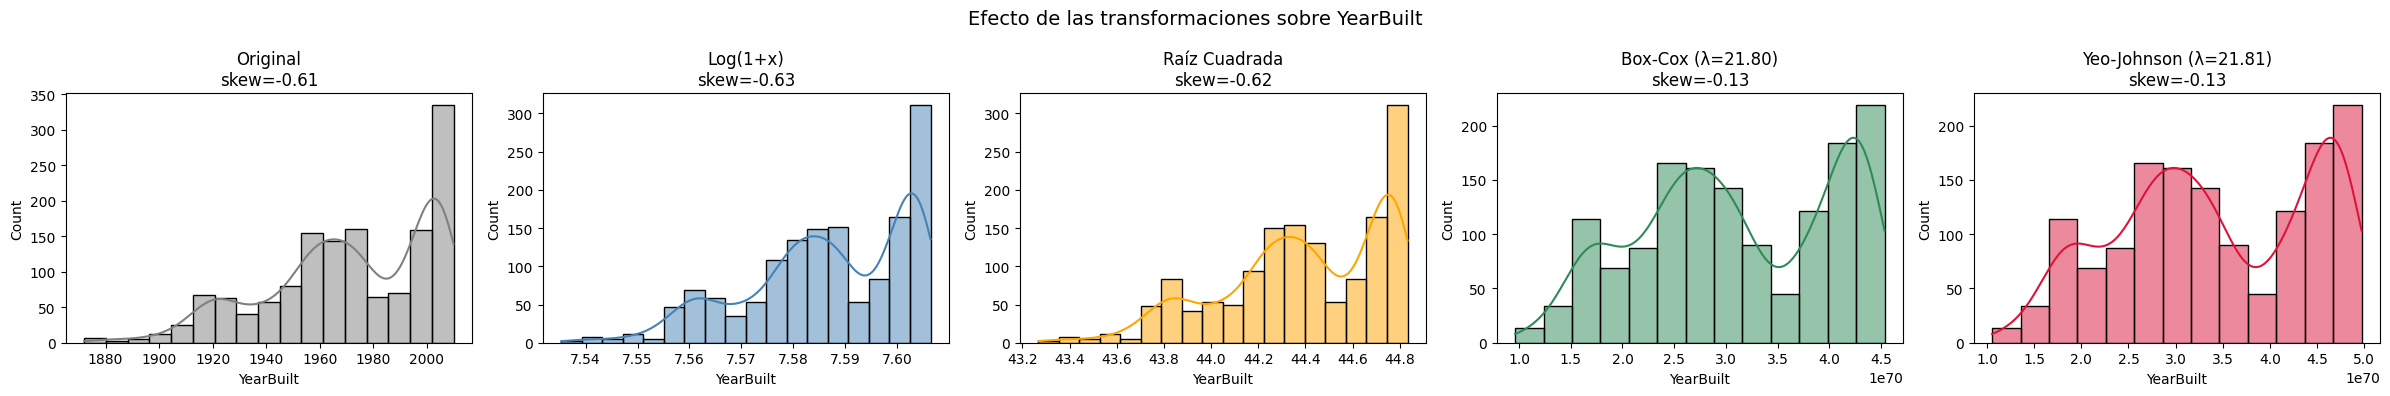

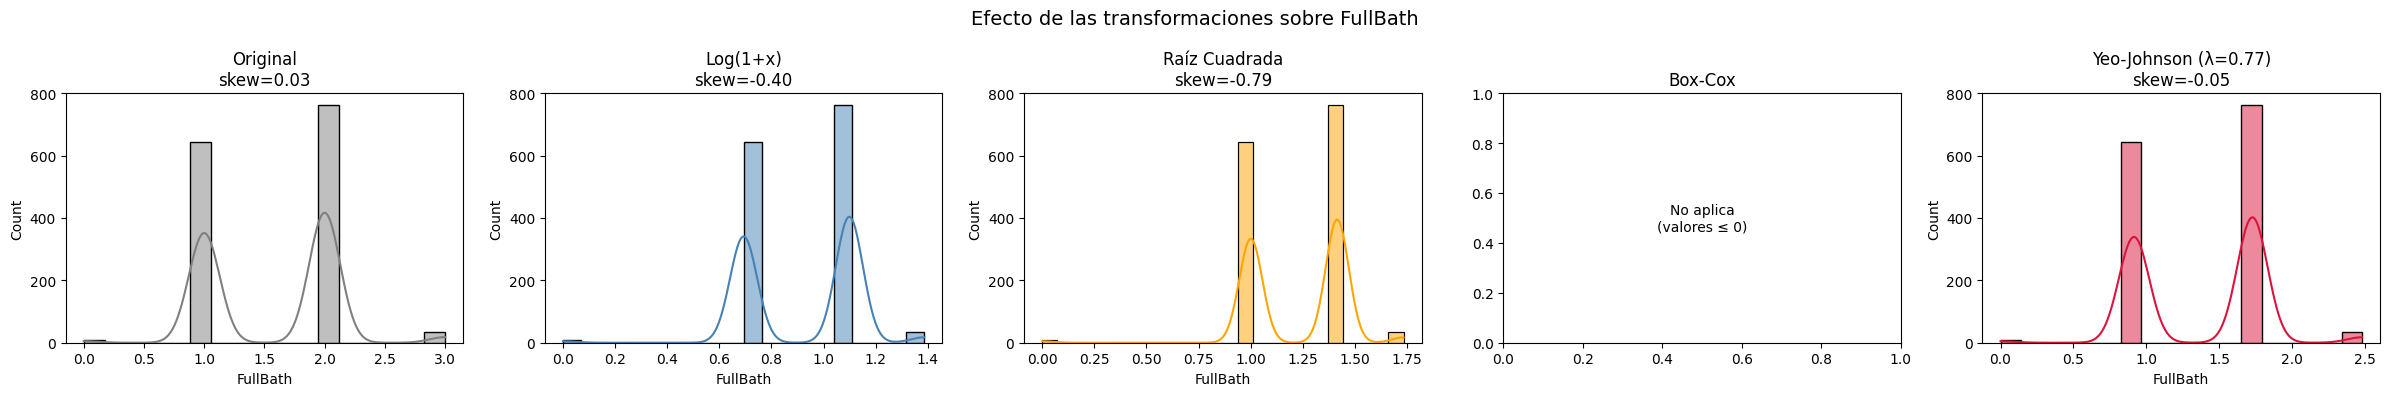

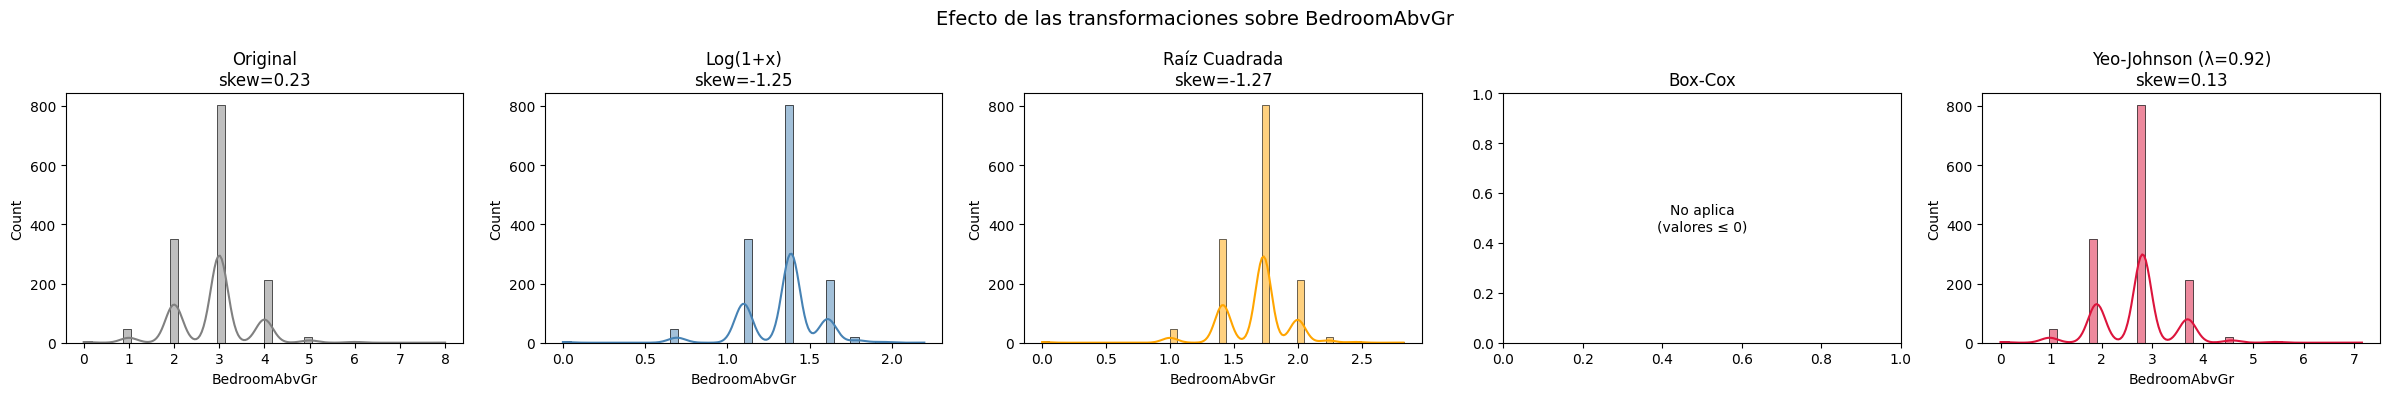

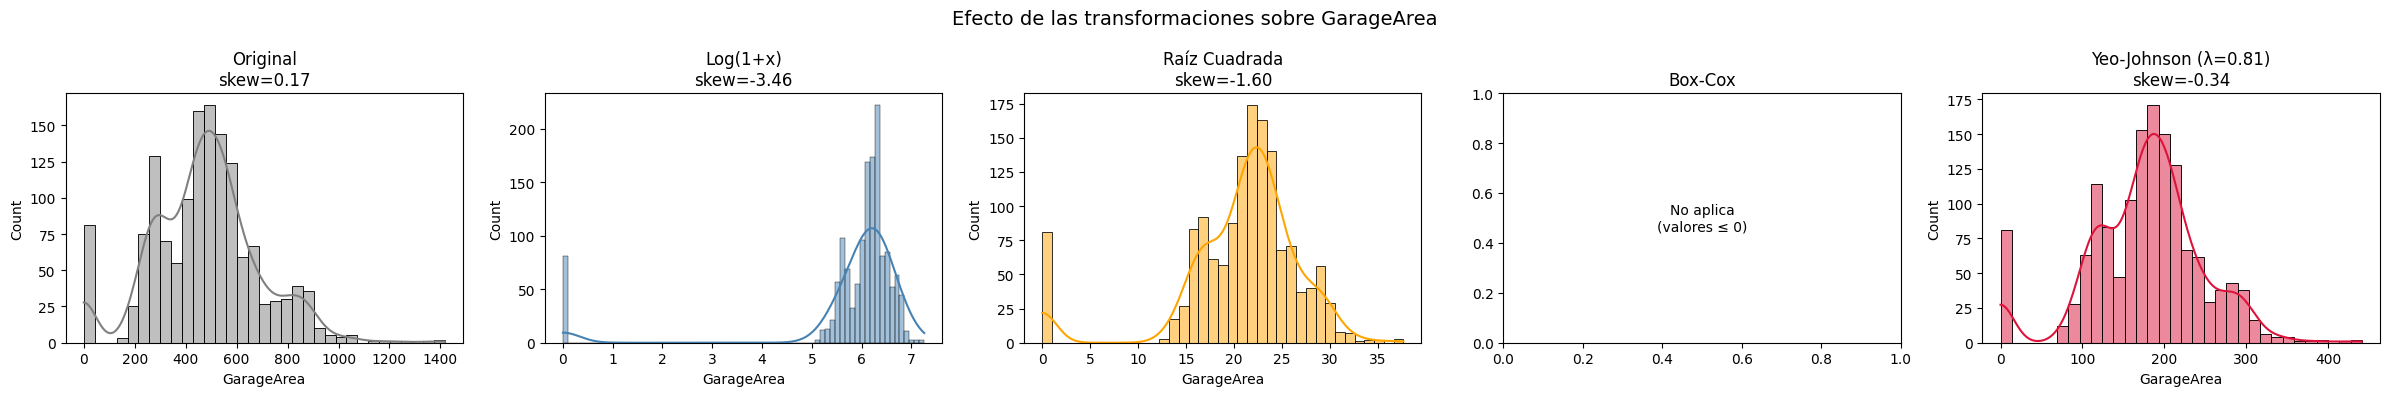

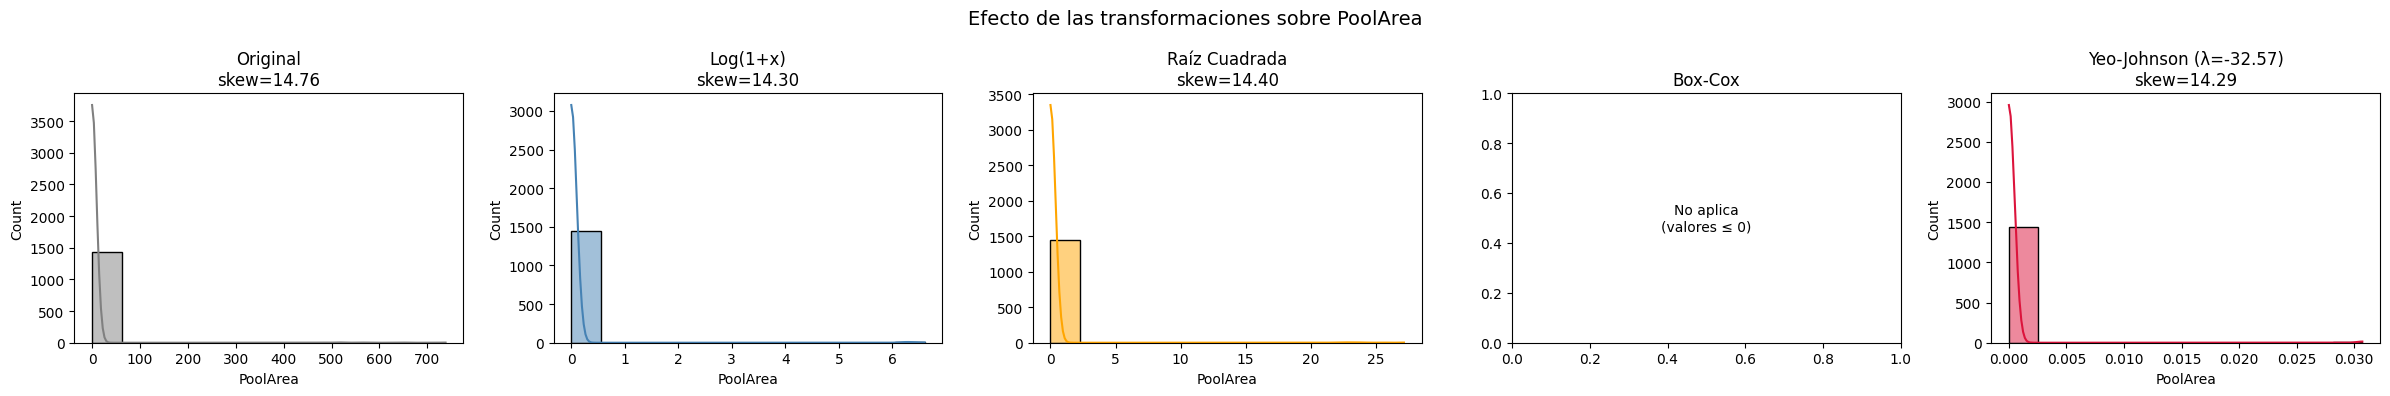

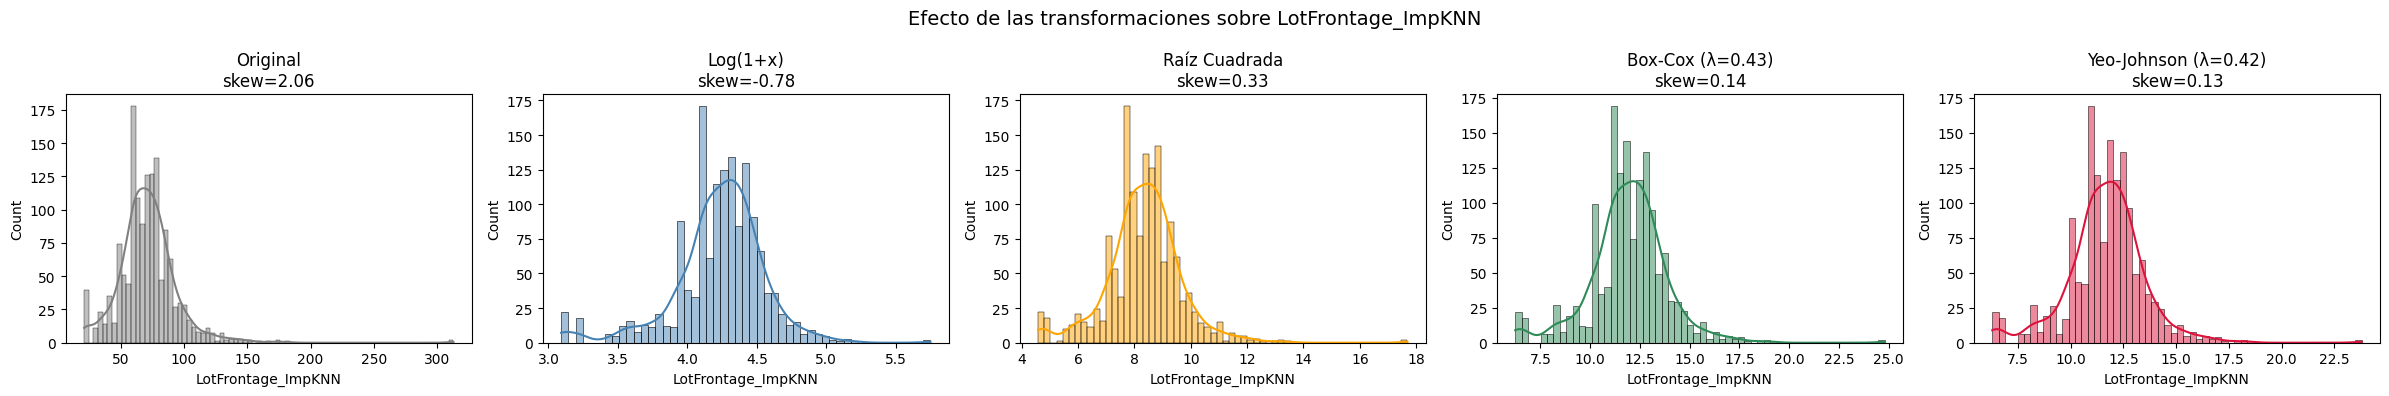

In [44]:
for col in data_num.columns:
    fig, axes = plt.subplots(1, 5, figsize=(24, 4))

    # Original
    sns.histplot(data_num[col], kde=True, ax=axes[0], color='gray')
    axes[0].set_title(f'Original\nskew={data_num[col].skew():.2f}')

    # Logaritmo natural (log1p)
    sns.histplot(data_log[col], kde=True, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Log(1+x)\nskew={data_log[col].skew():.2f}')

    # Raíz cuadrada
    sns.histplot(data_sqrt[col], kde=True, ax=axes[2], color='orange')
    axes[2].set_title(f'Raíz Cuadrada\nskew={data_sqrt[col].skew():.2f}')

    # Box-Cox (si la variable tiene ceros o negativos, no se pudo aplicar)
    if resultados_boxcox[col]['lambda'] is not None:
        sns.histplot(df_boxcox[col], kde=True, ax=axes[3], color='seagreen')
        axes[3].set_title(f"Box-Cox (λ={resultados_boxcox[col]['lambda']:.2f})\nskew={df_boxcox[col].skew():.2f}")
    else:
        axes[3].text(0.5, 0.5, 'No aplica\n(valores ≤ 0)', ha='center', va='center', transform=axes[3].transAxes)
        axes[3].set_title('Box-Cox')

    # Yeo-Johnson
    sns.histplot(df_yeojohnson[col], kde=True, ax=axes[4], color='crimson')
    axes[4].set_title(f"Yeo-Johnson (λ={resultados_yeojohnson[col]['lambda']:.2f})\nskew={df_yeojohnson[col].skew():.2f}")

    fig.suptitle(f'Efecto de las transformaciones sobre {col}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [45]:
# Shapiro-Wilk por variable y por transformación
# ojo: con este dataset (~1460 filas) no hay problema de tamaño de muestra para el test
resultados_shapiro = []

for col in data_num.columns:
    fila = {'Variable': col}

    fila['p_Original'] = shapiro(data_num[col])[1]
    fila['p_Log'] = shapiro(data_log[col])[1]
    fila['p_Sqrt'] = shapiro(data_sqrt[col])[1]
    fila['p_BoxCox'] = shapiro(df_boxcox[col])[1] if resultados_boxcox[col]['lambda'] is not None else np.nan
    fila['p_YeoJohnson'] = shapiro(df_yeojohnson[col])[1]

    resultados_shapiro.append(fila)

df_shapiro = pd.DataFrame(resultados_shapiro).set_index('Variable').round(4)
display(df_shapiro)

,p_Original,p_Log,p_Sqrt,p_BoxCox,p_YeoJohnson
Variable,,,,,
SalePrice,0.0,0.0,0.0,0.0,0.0
LotArea,0.0,0.0,0.0,0.0,0.0
OverallCond,0.0,0.0,0.0,0.0,0.0
YearBuilt,0.0,0.0,0.0,0.0,0.0
FullBath,0.0,0.0,0.0,NaN,0.0
BedroomAbvGr,0.0,0.0,0.0,NaN,0.0
GarageArea,0.0,0.0,0.0,NaN,0.0
PoolArea,0.0,0.0,0.0,NaN,0.0
LotFrontage_ImpKNN,0.0,0.0,0.0,0.0,0.0
